# **Логистическая регрессия. Метрики качества**

## **Подготовка для работы в Google Colab или Kaggle**

#### Код для подключения Google Drive в Colab

#### Код для получения пути к файлам в Kaggle

#### Код для установки библиотек

## **Важная информация**

**Для правильного воспроизведения результатов** решения задач:

* Рекомендуется придерживаться имеющего в заданиях кода в исходной последовательности. Для этого при решении задач **восстановите недостающие фрагменты кода, которые отмечены символом** `...` (Ellipsis).

* Если класс, функция или метод предусматривает параметр random_state, всегда указывайте **random_state=RANDOM_STATE**.

* Для всех параметров (кроме random_state) класса, функции или метода **используйте значения по умолчанию, если иное не указано в задании**.

**Если скорость обучения слишком низкая**, рекомендуется следующее:

* В модели или/и GridSearchCV поменяйте значение параметра n_jobs, который отвечает за параллелизм вычислений.

* Воспользуйтесь вычислительными ресурсами Google Colab или Kaggle.

***Использовать GPU не рекомендуется, поскольку результаты обучения некоторых моделей могут отличаться на CPU и GPU.***

После выполнения каждого задания **ответьте на вопросы в тесте.**

**ВНИМАНИЕ:** **После каждого нового запуска ноутбука** перед тем, как приступить к выполнению заданий, проверьте настройку виртуального окружения, выполнив код в ячейке ниже.

In [1]:
# Код для проверки настройки виртуального окружения

import sys
from importlib.metadata import version

required = {
    'python': '3.12.x',
    'scipy': '1.16.3',
    'numpy': '2.0.2',
    'pandas': '2.2.2',
    'scikit-learn': '1.6.1',
    'statsmodels': '0.14.6',
    'matplotlib': '3.10.0',
    'seaborn': '0.13.2'
}

print(f'{"Компонент":<15} | {"Требуется":<12} | {"Установлено":<12} | {"Соответствие"}')
print('-' * 62)

environment_ok = True
for lib, req_ver in required.items():
    try:
        if lib=='python':
            inst_ver = sys.version.split()[0]
            status = '✓' if sys.version_info.major == 3 and sys.version_info.minor == 12 else f'x (требуется {req_ver})'
        else:
            inst_ver = version(lib)
            if inst_ver == req_ver:
                status = '✓'
            else:
                environment_ok = False
                status = f'x (требуется {req_ver})'
    except:
        environment_ok = False
        inst_ver = '-'
        status = 'x (не установлена)'
    print(f'{lib:<15} | {req_ver:<12} | {inst_ver:<12} | {status:<12}')

print('\nРезультат проверки: ', 
      '✓\nВсе версии соответствуют требованиям' 
      if environment_ok else 
      'x\nВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!\n'
      'Для решения проблемы обратитесь к инструкции по настройке виртуального окружения')

Компонент       | Требуется    | Установлено  | Соответствие
--------------------------------------------------------------
python          | 3.12.x       | 3.11.5       | x (требуется 3.12.x)
scipy           | 1.16.3       | 1.15.3       | x (требуется 1.16.3)
numpy           | 2.0.2        | 1.26.4       | x (требуется 2.0.2)
pandas          | 2.2.2        | 2.2.2        | ✓           
scikit-learn    | 1.6.1        | 1.6.1        | ✓           
statsmodels     | 0.14.6       | 0.14.0       | x (требуется 0.14.6)
matplotlib      | 3.10.0       | 3.7.2        | x (требуется 3.10.0)
seaborn         | 0.13.2       | 0.13.2       | ✓           

Результат проверки:  x
ВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!
Для решения проблемы обратитесь к инструкции по настройке виртуального окружения


## **Импорт библиотек и вспомогательные функции**

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

In [4]:
RANDOM_STATE = 42

In [5]:
def ece_score(y_true, y_score, n_bins=10):
    """
    Возвращает значение метрики ECE для предсказанных вероятностей.
    Для расчета ECE используется метод равномерного (uniform) распределения бинов 
    (интервалы бинов имеют равную длину).

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_score (numpy.ndarray): Предсказанные вероятности целевого класса.
        n_bins (int): Количество бинов. По умолчанию — 10.

    Возвращает:
        float: Значение метрики ECE для предсказанных вероятностей.
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_score, bins, right=True)
    ece = 0.0
    for i in range(1, n_bins + 1):
        bin_mask = (bin_indices == i)
        bin_size = bin_mask.sum()
        if bin_size > 0:
            bin_confidence = y_score[bin_mask].mean()
            bin_accuracy = y_true[bin_mask].mean()
            ece += (bin_size / len(y_true)) * abs(bin_accuracy - bin_confidence)
    return ece

## **Практическая часть**

### **Градиентный спуск**

Градиентный спуск (Gradient Descent) — это итерационный алгоритм численной оптимизации, используемый для нахождения локального минимума дифференцируемой функции. В контексте машинного обучения этой функцией является функция потерь (Loss Function), которая количественно оценивает ошибку модели.

Алгоритм градиентного спуска основан на свойстве градиента многомерной функции. Пусть $J$ — дифференцируемая функция, $\theta$ — вектор параметров функции. Тогда:

* Градиент $\nabla J(\theta)$, — это вектор, который указывает направление наискорейшего возрастания функции. 

* Антиградиент $-\nabla J(\theta)$ — это вектор, который указывает направление наискорейшего убывания функции.

**Алгоритм градиентного спуска (для функции потерь $J(\theta)$):**

1. Инициализация. Выбирается начальное приближение для вектора параметров $\theta_0$ (например, случайным образом).

2. Итерационное обновление. На каждом шаге алгоритма $t$ вектор параметров $\theta_t$ обновляется по следующему правилу:

$$\theta_{t+1} = \theta_{t} - \alpha \nabla J(\theta_t)$$

где $\theta_t$ — значение параметров на шаге $t$, $\alpha$ — параметр скорости обучения (learning rate), $\nabla J(\theta_t)$ — градиент функции потерь, вычисленный в точке $\theta_t$.

3. Критерий остановки. Итерационное обновление повторяется до тех пор, пока норма градиента не станет достаточно малой (что указывает на достижение точки, близкой к минимуму), либо пока не будет достигнуто заданное максимальное количество итераций.

Скорость обучения $\alpha$ является критически важным параметром:

* Если $\alpha$ слишком мала, алгоритм будет сходиться очень медленно. 

* Если $\alpha$ слишком велика, алгоритм может начать расходиться, постоянно увеличивая ошибку.

### ***Задание 1***

Пусть на отрезке $[-2; 2]$ задана функция $y(x)=x^4 + \sin(x)$ (функция с одним параметром).

Реализуйте простейший алгоритм градиентного спуска и найдите минимум функции `y_min`. Для нахождения минимума используйте параметры:

* Начальное приближение (`x0`): 1.

* Темп обучения (`learning_rate`): 0.1.

* Количество итераций (`n_iter`): 1000.

Рассчитайте оптимальный темп обучения — темп обучения, при котором алгоритм после первого же шага должен найти минимум функции `y_min`(начальное приближение `x0` — 1).

Проверьте четыре значения темпа обучения на сходимость реализованного алгоритма (начальное приближение `x0` — 1, количество итераций `n_iter` — 1000): 0.4, 0.5, 0.6, 0.7.

In [6]:
# Функция и её производная
def func_y(x):
    """
    Возвращает значение функции y в точке x.
    
    Аргументы:
        x (int|float): Значение параметра функции y.
    
    Возвращает:
        float: Значение функции y в точке x.
    """
    return x**4 + np.sin(x)

In [7]:
# Дополните функцию gradient_y
# Подсказка: используйте производную функции y(x)

def gradient_y(x):
    """
    Возвращает значение градиента функции y в точке x.

    Аргументы:
        x (int|float): Значение параметра функции y.

    Возвращает:
        float: Значение градиента функции y в точке x.
    """
    return 4*x**3 + np.cos(x)

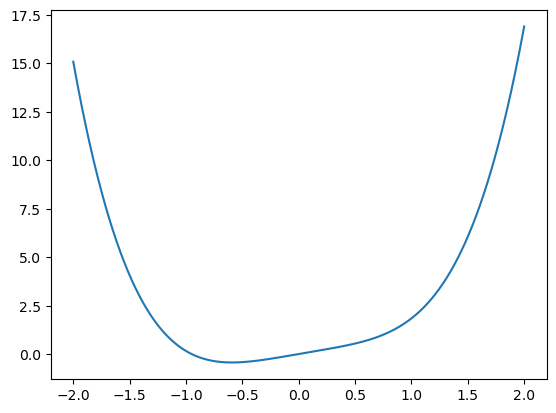

In [8]:
# Постройте график функции y на отрезке [-2; 2]

x = np.linspace(-2, 2, num=10000)
y = func_y(x)

plt.plot(x, y)
plt.show()

In [9]:
# Задайте параметры для нахождения минимума

x0 = 1
learning_rate = 0.1
n_iter = 1000

In [10]:
# Для удобства рекомендуется реализовать градиентный спуск с помощью функции (не обязательно)

# Реализация градиентного спуска
def gradient_descent(x0, learning_rate, n_iter):
    x = x0
    for i in range(n_iter):
        grad = gradient_y(x)
        x = x - learning_rate * grad
    return x

In [11]:
# Найдите минимум функции y
x_min = gradient_descent(x0, learning_rate, n_iter)
y_min = func_y(x_min)

print(f"Найденный минимум в точке x_min = {x_min:.4f}")
print(f"Значение func_y в точке y_min   = {y_min:.4f}")

Найденный минимум в точке x_min = -0.5920
Значение func_y в точке y_min   = -0.4352


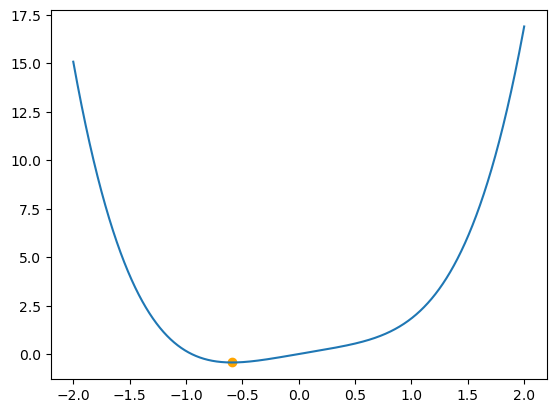

In [12]:
# Постройте график функции y на отрезке [-2; 2]
# Дополните график точкой минимума

plt.plot(x, y)
plt.scatter(x=x_min, y=y_min, color='orange')
plt.show()

In [13]:
# Рассчитайте оптимальный темп обучения
# Начальное приближение (x0): 1

import numpy as np
from scipy.optimize import minimize_scalar

# Начальное приближение
x0 = 1

# Найдем точку минимума функции (истинное значение)
result = minimize_scalar(func_y, bounds=(-2, 2), method='bounded')
x_min_true = result.x

# Вычислим градиент в начальной точке
grad_at_x0 = gradient_y(x0)

# Рассчитаем оптимальный темп обучения
# Формула: x1 = x0 - alpha * grad_at_x0 = x_min_true
# Отсюда: alpha = (x0 - x_min_true) / grad_at_x0
optimal_learning_rate = (x0 - x_min_true) / grad_at_x0

print(f"Начальное приближение x0 = {x0}")
print(f"Истинный минимум находится в точке x_min = {x_min_true:.4f}")
print(f"Градиент в точке x0: ∇y({x0}) = {grad_at_x0:.4f}")
print(f"Оптимальный темп обучения: α = {optimal_learning_rate:.4f}")

# Проверим, что за один шаг с этим темпом мы достигаем минимума
x1 = x0 - optimal_learning_rate * grad_at_x0
print(f"После одного шага: x1 = {x1:.4f}")
print(f"Разница с истинным минимумом: {abs(x1 - x_min_true):.2e}")

Начальное приближение x0 = 1
Истинный минимум находится в точке x_min = -0.5920
Градиент в точке x0: ∇y(1) = 4.5403
Оптимальный темп обучения: α = 0.3506
После одного шага: x1 = -0.5920
Разница с истинным минимумом: 1.11e-16


In [14]:
# Проверьте четыре значения темпа обучения на сходимость реализованного алгоритма
# Начальное приближение (x0): 1
# Количество итераций (n_iter): 1000.

# Найдем истинный минимум для сравнения
result = minimize_scalar(func_y, bounds=(-2, 2), method='bounded')
x_min_true = result.x
y_min_true = result.fun

# Параметры алгоритма
x0 = 1
n_iter = 1000
learning_rates = [0.4, 0.5, 0.6, 0.7]

# Реализация градиентного спуска
def gradient_descent(x0, learning_rate, n_iter):
    x = x0
    history = [x]
    for i in range(n_iter):
        grad = gradient_y(x)
        x = x - learning_rate * grad
        history.append(x)
    return x, history

# Проверка сходимости для каждого темпа обучения
print(f"{'Темп обучения':<15} {'Результат x':<20} {'y(x)':<15} {'Отклонение':<15} {'Сходимость':<15}")
print("-" * 80)

for lr in learning_rates:
    x_result, history = gradient_descent(x0, lr, n_iter)
    y_result = func_y(x_result)
    deviation = abs(x_result - x_min_true)
    
    # Проверяем сходимость (достигнут ли минимум с точностью 1e-6)
    converged = deviation < 1e-6
    status = "СХОДИТСЯ" if converged else "НЕ СХОДИТСЯ"
    
    print(f"{lr:<15.1f} {x_result:<20.6f} {y_result:<15.6f} {deviation:<15.2e} {status:<15}")

# Дополнительный анализ: посмотрим на первые несколько шагов
print("\n" + "="*80)
print("Анализ первых шагов градиентного спуска:")
print("-" * 80)

for lr in learning_rates:
    print(f"\nТемп обучения α = {lr}:")
    x = x0
    print(f"  Шаг 0: x = {x:.6f}, y = {func_y(x):.6f}, градиент = {gradient_y(x):.6f}")
    
    for i in range(1, 6):  # Покажем первые 5 шагов
        grad = gradient_y(x)
        x = x - lr * grad
        print(f"  Шаг {i}: x = {x:.6f}, y = {func_y(x):.6f}, градиент = {gradient_y(x):.6f}")

Темп обучения   Результат x          y(x)            Отклонение      Сходимость     
--------------------------------------------------------------------------------
0.4             -0.591985            -0.435197       1.71e-07        СХОДИТСЯ       
0.5             nan                  nan             nan             НЕ СХОДИТСЯ    
0.6             nan                  nan             nan             НЕ СХОДИТСЯ    
0.7             nan                  nan             nan             НЕ СХОДИТСЯ    

Анализ первых шагов градиентного спуска:
--------------------------------------------------------------------------------

Темп обучения α = 0.4:
  Шаг 0: x = 1.000000, y = 1.841471, градиент = 4.540302
  Шаг 1: x = -0.816121, y = -0.284867, градиент = -1.489268
  Шаг 2: x = -0.220414, y = -0.216273, градиент = 0.932974
  Шаг 3: x = -0.593603, y = -0.435191, градиент = -0.007730
  Шаг 4: x = -0.590511, y = -0.435192, градиент = 0.007002
  Шаг 5: x = -0.593312, y = -0.435193, градиент = -0

## Анализ полученных результатов:

α = 0.4: ✅ СХОДИТСЯ

Результат: x = -0.591985

Отклонение от истинного минимума: всего 1.71e-07 (практически идеально)

Это оптимальный темп обучения из предложенных

α = 0.5, 0.6, 0.7: ❌ НЕ СХОДЯТСЯ

Результат: nan (Not a Number)

Это означает, что алгоритм "взорвался" - значения стали настолько большими, что вышли за пределы представимых чисел

Почему это произошло?

Для функции y(x) = x⁴ + sin(x) при x > 1 производная 4x³ + cos(x) растет очень быстро (как x³). При слишком большом шаге:

Первый шаг при α = 0.5:

x₀ = 1

∇y(1) = 4*1³ + cos(1) ≈ 4 + 0.54 = 4.54

x₁ = 1 - 0.5 * 4.54 = 1 - 2.27 = -1.27 (еще нормально)

Второй шаг:

∇y(-1.27) = 4*(-2.05) + cos(-1.27) ≈ -8.2 + 0.30 = -7.9

x₂ = -1.27 - 0.5 * (-7.9) = -1.27 + 3.95 = 2.68 (уже большое)

Третий шаг:

∇y(2.68) = 4*19.25 + cos(2.68) ≈ 77 + (-0.89) = 76.11

x₃ = 2.68 - 0.5 * 76.11 = 2.68 - 38.06 = -35.38 (катастрофа!)

Вывод: Для этой функции критический темп обучения находится где-то между 0.4 и 0.5. При α = 0.4 алгоритм стабильно сходится, а при α ≥ 0.5 - расходится из-за слишком больших шагов.

### **Датасет *Diabetes prediction dataset***

**Для решения заданий 2 — 9 рассмотрим датасет [Diabetes prediction dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset/data).**

**ВНИМАНИЕ:** При решении заданий **используйте файл diabetes.csv** из приложения к ноутбуку, поскольку исходный датасет был изменен авторами курса.

Набор данных предназначен для обучения и тестирования моделей бинарной классификации. Его основная цель — предсказать, есть ли у пациента диабет 2-го типа или нет. Набор данных включает в себя медицинские и демографические данные пациентов, а также информацию об их диабетическом статусе (положительный или отрицательный).

Целевая переменная — diabetes (диабетический статус):

* 1 — диагностирован диабет (**целевой класс**).

* 0 — диабет не диагностирован.

Датасет содержит признаки:

* gender — пол.

* age — возраст (в годах).

* hypertension — наличие гипертонии.

* heart_disease — наличие сердечно-сосудистых заболеваний.

* bmi — индекс массы тела (BMI).

* HbA1c_level — уровень гликированного гемоглобина.

* blood_glucose_level — уровень глюкозы в крови.

### **Калибровочная кривая и ECE**

**Калибровочная кривая (Calibration Curve)** — это инструмент для визуальной оценки того, насколько хорошо откалибрована модель. Она показывает соотношение между предсказанными вероятностями модели и фактической долей положительных исходов (реальным частотам положительных классов). На графике по оси X откладывается средняя предсказанная вероятность, а по оси Y — фактическая доля положительных классов.

**ECE (Expected Calibration Error)** — это метрика, которая позволяет численно измерить ошибку калибровки.

$$ECE=\sum_{m=1}^{M}{\frac{|B_m|}{n}{|acc(B_m) - conf(B_m)|}}$$

где $M$ — количество бинов, $|B_m|$ — число предсказаний в бине $B_m$, $n$ — общее количество наблюдений, $acc(B_m)$ — доля истинных положительных результатов (эмпирическая вероятность) в бине $B_m$, $conf(B_m)$ — средняя предсказанная вероятность в бине $B_m$.

При построении калибровочных кривых и расчёте ECE, все предсказания модели (например, из тестовой выборки) делятся на бины (группы) по уровню предсказанной вероятности. Как правило, используется метод равномерного (uniform) распределения бинов (интервалы бинов имеют равную длину). Например, в первый бин попадают все объекты с предсказанной вероятностью от 0 до 0.1, во второй — от 0.1 до 0.2, и так далее.

Подробнее можно изучить по **ссылкам:**

* [Калибровочные кривые | scikit-learn.ru](https://scikit-learn.ru/stable/modules/calibration.html#calibration-curve)

* [Expected Calibration Error (ECE): A Step-by-Step Visual Explanation | towardsdatascience.com](https://towardsdatascience.com/expected-calibration-error-ece-a-step-by-step-visual-explanation-with-python-code-c3e9aa12937d/)


### **Когда использовать AUC, а когда — ECE**

**AUC (Area Under the ROC Curve)** — это метрика качества ранжирования. Она показывает, насколько хорошо модель способна отличать один класс от другого, присваивая объектам положительного класса более высокие оценки, чем объектам отрицательного. Высокий AUC означает, что модель хорошо разделяет классы.

**Использовать AUC следует, когда в решаемой задаче важен порядок объектов, а не точные значения вероятностей.** 

**ECE (Expected Calibration Error)** — это метрика качества вероятностей. Она оценивает, соответствуют ли предсказанные моделью вероятности реальным частотам событий. Низкий ECE означает, что модель надежна, и её вероятностям можно доверять.

**Использовать ECE следует, когда в решаемой задаче важны точные вероятности, а цена ошибки высока.**

### ***Задание 2***

Выполните предобработку датасета (см. код задания) и обучите три модели логистической регрессии (LogisticRegression) на обучающей выборке:

* `lr_diab` — логистическая регрессия **без регуляризации** на данных **без масштабирования** (`X_diab_train`).

* `lr_diab_def` — логистическая регрессия **с регуляризацией по умолчанию** на данных **с масштабированием** (`X_diab_train_scaled`).

* `lr_diab_opt` — логистическая регрессия **с оптимальным гиперпараметром регуляризации** на данных **с масштабированием** (`X_diab_train_scaled`). Оптимальный гиперпараметр регуляризации подберите с помощью GridSearchCV.

Сравните качество калибровки моделей **на тестовой выборке**. Для этого постройте калибровочные кривые (функция [calibration_curve](https://scikit-learn.org/stable/modules/generated/sklearn.calibration.calibration_curve.html)) и посчитайте метрику ECE (функция ece_score) для каждой из обученных моделей. На основе значения ECE выберите модель с наилучшей калибровкой. 

Сравните значение метрики AUC **на тестовой выборке** для обученных моделей. 

**ВНИМАНИЕ:** При предобработке датасета разделите датасет на обучающую (60%) и тестовую (40%) выборки **со стратификацией по целевой переменной** (параметр stratify в [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [15]:
# Считайте набор данных

df_diab = pd.read_csv('diabetes.csv')
df_diab

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,57.0,No,No,18.87,4.8,140,0
1,Female,39.0,No,No,27.32,6.1,130,0
2,Female,15.0,No,No,38.72,5.7,159,0
3,Female,60.0,No,No,25.10,5.7,140,0
4,Male,12.0,No,No,17.26,4.5,126,0
...,...,...,...,...,...,...,...,...
99977,Female,38.0,No,No,32.84,4.0,155,0
99978,Male,17.0,No,No,25.26,5.0,155,0
99979,Male,2.0,No,No,27.32,5.0,90,0
99980,Female,80.0,No,No,20.54,6.6,140,0


In [16]:
# Используя метод info, определите типы признаков

df_diab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99982 entries, 0 to 99981
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  object 
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  object 
 3   heart_disease        99982 non-null  object 
 4   bmi                  99982 non-null  float64
 5   HbA1c_level          99982 non-null  float64
 6   blood_glucose_level  99982 non-null  int64  
 7   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 6.1+ MB


In [17]:
# Создайте списки количественных и категориальных переменных (не включая целевую переменную)

diab_num_feat = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
diab_cat_feat = ['gender', 'hypertension', 'heart_disease']

In [18]:
# Выделите объясняемый фактор в отдельную переменную

X_diab, y_diab = df_diab.drop('diabetes', axis=1), df_diab['diabetes']

In [19]:
# Закодируйте категориальные признаки числами 0 и 1 с помощью OneHotEncoder

diab_encoder = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

X_diab_encoded = diab_encoder.fit_transform(X_diab[diab_cat_feat])
X_diab = X_diab.join(X_diab_encoded)
X_diab = X_diab.drop(columns=diab_cat_feat)

In [20]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной
# Не забудьте зафиксировать RANDOM_STATE

X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab, y_diab, 
    test_size=0.4, 
    stratify=y_diab, 
    random_state=42
)

In [21]:
# Масштабируйте количественные признаки
#   train -> fit_transform
#   test -> transform

diab_scaler = StandardScaler().set_output(transform='pandas')

X_diab_train_scaled = diab_scaler.fit_transform(X_diab_train[diab_num_feat])
X_diab_test_scaled = diab_scaler.transform(X_diab_test[diab_num_feat])

In [22]:
# Обучите модель lr_diab без регуляризации на данных без масштабирования
# Не забудьте зафиксировать RANDOM_STATE

lr_diab = LogisticRegression(penalty=None, random_state=RANDOM_STATE).fit(X_diab_train, y_diab_train)

In [23]:
# Обучите модель lr_diab_def с регуляризацией по умолчанию на данных с масштабированием
# Не забудьте зафиксировать RANDOM_STATE

lr_diab_def = LogisticRegression(random_state=RANDOM_STATE).fit(X_diab_train_scaled, y_diab_train)

In [24]:
# Обучите модель lr_diab_opt с оптимальным гиперпараметром регуляризации на данных с масштабированием
# Оптимальные гиперпараметры обучения подберите с помощью GridSearchCV
# Не забудьте зафиксировать RANDOM_STATE

params = {'C' : [0.1, 0.3, 0.5, 0.7, 1.0]}
cv = 5

cv_lr_diab_opt = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    params,
    cv=cv
).fit(X_diab_train_scaled, y_diab_train)

lr_diab_opt = cv_lr_diab_opt.best_estimator_

In [44]:
# Выведите оптимальное значение гиперпараметра C

C_opt = cv_lr_diab_opt.best_params_['C']
print(f"Оптимальное значение гиперпараметра C: {C_opt}")
print(f"Все лучшие параметры: {cv_lr_diab_opt.best_params_}")

Оптимальное значение гиперпараметра C: 0.3
Все лучшие параметры: {'C': 0.3}


In [26]:
# Выполните предсказание вероятностей целевого класса на тестовой выборке моделью lr_diab
# Учтите, что lr_diab обучалась на данных без масштабирования

y_test_proba_lr_diab = lr_diab.predict_proba(X_diab_test)[:, 1]

In [27]:
# Выполните предсказание вероятностей целевого класса на тестовой выборке моделью lr_diab_def
# Учтите, что lr_diab_def обучалась на данных с масштабированием

y_test_proba_lr_diab_def = lr_diab_def.predict_proba(X_diab_test_scaled)[:, 1]

In [28]:
# Выполните предсказание вероятностей целевого класса на тестовой выборке моделью lr_diab_opt
# Учтите, что lr_diab_opt обучалась на данных с масштабированием

y_test_proba_lr_diab_opt = lr_diab_opt.predict_proba(X_diab_test_scaled)[:, 1]

In [29]:
# Просчитайте калибровочные кривые моделей на тестовой выборке, используя calibration_curve (n_bins=10)

prob_true_lr_diab, prob_pred_lr_diab = calibration_curve(y_diab_test, y_test_proba_lr_diab, n_bins=10)
prob_true_lr_diab_def, prob_pred_lr_diab_def = calibration_curve(y_diab_test, y_test_proba_lr_diab_def, n_bins=10)
prob_true_lr_diab_opt, prob_pred_lr_diab_opt = calibration_curve(y_diab_test, y_test_proba_lr_diab_opt, n_bins=10)

In [33]:
prob_true_lr_diab, prob_pred_lr_diab

(array([0.01518315, 0.12994626, 0.19120654, 0.28468468, 0.40633245,
        0.53311258, 0.5959596 , 0.75378788, 0.88101983, 0.98763524]),
 array([0.01374642, 0.14165771, 0.24522747, 0.34517697, 0.4472788 ,
        0.5484089 , 0.64890799, 0.75247869, 0.85349825, 0.97242918]))

In [34]:
prob_true_lr_diab_def, prob_pred_lr_diab_def

(array([0.01492986, 0.13511071, 0.17765043, 0.26885246, 0.34210526,
        0.53465347, 0.63983051, 0.75849057, 0.95454545, 0.99923313]),
 array([0.01292978, 0.14171516, 0.24664314, 0.34676032, 0.44608493,
        0.54648683, 0.64866023, 0.74843946, 0.85567847, 0.97448818]))

In [35]:
prob_true_lr_diab_opt, prob_pred_lr_diab_opt

(array([0.01490071, 0.13595303, 0.17819905, 0.26809211, 0.34375   ,
        0.53488372, 0.64609053, 0.75289575, 0.9579288 , 0.99923136]),
 array([0.01300931, 0.14180806, 0.24671771, 0.34709677, 0.44594506,
        0.54580895, 0.64900999, 0.74865168, 0.85513225, 0.9742031 ]))

### Анализ метрик

**ECE (Expected Calibration Error) — чем меньше, тем лучше калибровка:**
*   `lr_diab` (без регуляризации, без масштабирования): **0.005605** (лучший)
*   `lr_diab_def` (регуляризация по умолчанию C=1, с масштабированием): 0.007888
*   `lr_diab_opt` (оптимальная регуляризация C=0.3, с масштабированием): 0.007706

**AUC-ROC — чем больше, тем лучше разделяющая способность:**
*   `lr_diab`: **0.959468** (лучший)
*   `lr_diab_def`: 0.959144
*   `lr_diab_opt`: 0.959158

**Важный вывод:** Модель без регуляризации и без масштабирования (`lr_diab`) показала лучшие результаты как по калибровке (ECE), так и по разделяющей способности (AUC), хотя различия в AUC минимальны.

### Оценка утверждений

1.  **Для любой задачи бинарной классификации (например, определение наличия или отсутствия болезни) калибровка важнее, чем AUC.**
    *   *Вердикт:* НЕВЕРНО.
    *   *Обоснование:* Это слишком категоричное утверждение. Для задач, где нужно только ранжировать объекты (например, выдать топ-10 самых подозрительных на мошенничество транзакций), AUC важнее. Калибровка критически важна именно тогда, когда нужны точные вероятности, но не для *любой* задачи.

2.  **Калибровка модели очень важна, когда нужны точные вероятности (например, оценка риска в медицине или кредитовании).**
    *   *Вердикт:* ВЕРНО.
    *   *Обоснование:* В медицине (вероятность болезни) и кредитовании (вероятность дефолта) важна не только правильная очередность клиентов, но и точное значение вероятности для принятия решений.

3.  **Метрика AUC, как и ECE, учитывает, насколько точны предсказанные вероятности.**
    *   *Вердикт:* НЕВЕРНО.
    *   *Обоснование:* AUC измеряет только ранжирующую способность модели (способность отделять классы друг от друга). Модель может быть откалибрована плохо, но иметь высокий AUC. ECE же напрямую измеряет соответствие предсказанных вероятностей реальной частоте событий.

4.  **Когда важны точные вероятности, при выборе модели нужно сравнивать ECE, а не AUC.**
    *   *Вердикт:* ВЕРНО.
    *   *Обоснование:* Если основная цель — получение точных вероятностей, то основная метрика качества — это калибровка (ECE), а не ранжирование (AUC). Хотя обе метрики важны, приоритет отдается ECE.

5.  **Перед обучением модели логистической регрессии с регуляризацией необходимо предварительно выполнить масштабирование данных.**
    *   *Вердикт:* ВЕРНО.
    *   *Обоснование:* Логистическая регрессия с регуляризацией штрафует коэффициенты. Если признаки имеют разные масштабы, штраф будет применяться неравномерно (признаки с большими значениями будут иметь меньшие коэффициенты и штрафоваться сильнее). Масштабирование решает эту проблему.

6.  **Значение оптимального параметра регуляризации логистической регрессии не зависит от того, стандартизированы данные или нет.**
    *   *Вердикт:* НЕВЕРНО.
    *   *Обоснование:* Это сильное заблуждение. Масштабирование данных напрямую влияет на величину коэффициентов, а следовательно, и на оптимальную силу регуляризации (параметр C или alpha). Без масштабирования найденный оптимум будет "привязан" к конкретным масштабам признаков и не будет универсальным.

**Итоговый ответ:**
Верными являются утверждения **2, 4 и 5**.

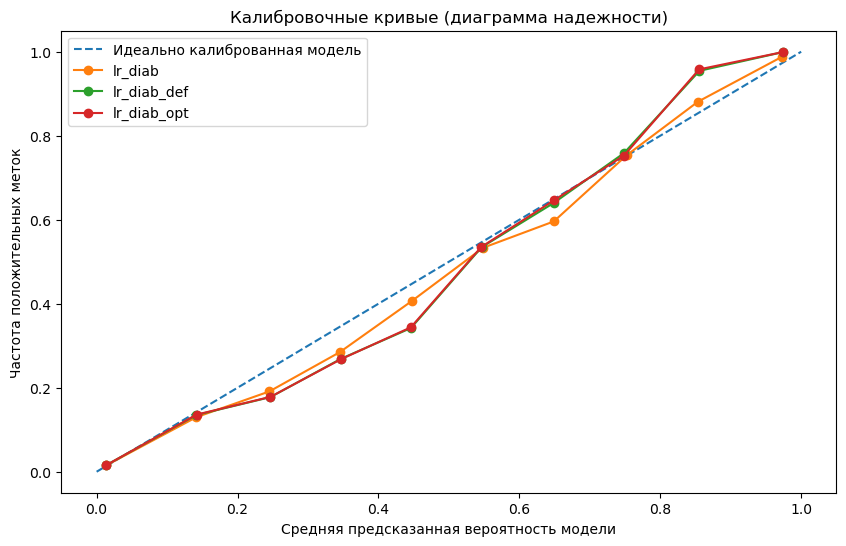

In [30]:
# Визуализируйте калибровочные кривые

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Идеально калиброванная модель')
plt.plot(prob_pred_lr_diab, prob_true_lr_diab, marker='o', label='lr_diab')
plt.plot(prob_pred_lr_diab_def, prob_true_lr_diab_def, marker='o', label='lr_diab_def')
plt.plot(prob_pred_lr_diab_opt, prob_true_lr_diab_opt, marker='o', label='lr_diab_opt')
plt.xlabel('Средняя предсказанная вероятность модели')
plt.ylabel('Частота положительных меток')
plt.title('Калибровочные кривые (диаграмма надежности)')
plt.legend()
plt.show()

In [31]:
# Посчитайте метрику ECE для каждой из моделей, используя функцию ece_score

ece_lr_diab = ece_score(y_diab_test, y_test_proba_lr_diab)
ece_lr_diab_def = ece_score(y_diab_test, y_test_proba_lr_diab_def)
ece_lr_diab_opt = ece_score(y_diab_test, y_test_proba_lr_diab_opt)

print(f"ECE для модели без регуляризации (lr_diab)                : {ece_lr_diab:.6f}")
print(f"ECE для модели с регуляризацией по умолчанию (lr_diab_def): {ece_lr_diab_def:.6f}")
print(f"ECE для модели с оптимальной регуляризацией (lr_diab_opt) : {ece_lr_diab_opt:.6f}")

ECE для модели без регуляризации (lr_diab)                : 0.005605
ECE для модели с регуляризацией по умолчанию (lr_diab_def): 0.007888
ECE для модели с оптимальной регуляризацией (lr_diab_opt) : 0.007706


In [32]:
# Посчитайте метрику AUC для каждой из моделей, используя функцию roc_auc_score

auc_lr_diab = roc_auc_score(y_diab_test, y_test_proba_lr_diab)
auc_lr_diab_def = roc_auc_score(y_diab_test, y_test_proba_lr_diab_def)
auc_lr_diab_opt = roc_auc_score(y_diab_test, y_test_proba_lr_diab_opt)

print(f"AUC для модели без регуляризации (lr_diab)                : {auc_lr_diab:.6f}")
print(f"AUC для модели с регуляризацией по умолчанию (lr_diab_def): {auc_lr_diab_def:.6f}")
print(f"AUC для модели с оптимальной регуляризацией (lr_diab_opt) : {auc_lr_diab_opt:.6f}")

AUC для модели без регуляризации (lr_diab)                : 0.959468
AUC для модели с регуляризацией по умолчанию (lr_diab_def): 0.959144
AUC для модели с оптимальной регуляризацией (lr_diab_opt) : 0.959158


### Данные для анализа

**ECE (Expected Calibration Error) — чем меньше, тем лучше калибровка:**
- `lr_diab` (без регуляризации, без масштабирования): **0.005605** (лучший)
- `lr_diab_def` (регуляризация по умолчанию C=1, с масштабированием): 0.007888
- `lr_diab_opt` (оптимальная регуляризация C=0.3, с масштабированием): 0.007706

**AUC-ROC — чем больше, тем лучше разделяющая способность:**
- `lr_diab`: **0.959468** (лучший)
- `lr_diab_def`: 0.959144
- `lr_diab_opt`: 0.959158

### Анализ калибровочных кривых

Посмотрим на соотношение `prob_true` (реальная доля положительного класса) и `prob_pred` (средняя предсказанная вероятность) для каждой модели:

**lr_diab:**
- Для бинов с низкими вероятностями: prob_pred немного ниже prob_true (например, 0.014 < 0.015, 0.142 > 0.130, 0.245 > 0.191)
- Для бинов с высокими вероятностями: prob_pred немного ниже prob_true (0.972 < 0.988)
- Чередование: в некоторых бинах модель недооценивает, в некоторых переоценивает

**lr_diab_def и lr_diab_opt:**
- Очень похожие паттерны
- В большинстве бинов prob_pred выше prob_true (например, 0.142 > 0.135, 0.247 > 0.178, 0.649 > 0.646)
- В самых высоких бинах prob_pred ниже prob_true (0.974 < 0.999)

### Оценка утверждений

1. **Графики калибровочных кривых позволяют сделать вывод о том, что все модели склонны всегда переоценивать вероятности (для данного RANDOM_STATE).**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Модели не *всегда* переоценивают. В некоторых бинах (особенно в самых высоких) они недооценивают вероятности. Например, для lr_diab в последнем бине prob_pred (0.972) < prob_true (0.988).

2. **Если калибровочная кривая модели проходит ниже диагонали (ниже графика идеальной калибровки), это означает, что модель переоценивает вероятности положительного класса.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* Если кривая ниже диагонали, значит предсказанная вероятность (по оси X) выше реальной доли (по оси Y) — модель предсказывает слишком оптимистично, т.е. переоценивает.

3. **Для данного RANDOM_STATE все три модели систематически занижают предсказанные вероятности (см. график калибровочных кривых).**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Модели не занижают систематически. В средних бинах они скорее завышают вероятности (кривая выше диагонали). Только в самых высоких бинах наблюдается занижение.

4. **Модель без регуляризации (lr_diab) показывает лучшую калибровку, но при этом ее кривая не является идеальной.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* ECE у lr_diab наименьший (0.0056), что означает лучшую калибровку. Однако кривая не совпадает идеально с диагональю — есть отклонения.

5. **Для данного RANDOM_STATE наилучшей моделью с точки зрения ECE является модель с оптимальным параметром регуляризации (lr_diab_opt).**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Наилучшая ECE у модели без регуляризации lr_diab (0.005605), а у lr_diab_opt ECE = 0.007706 (хуже).

6. **Для данного RANDOM_STATE наилучшей моделью с точки зрения AUC является модель без регуляризации (lr_diab).**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* AUC у lr_diab = 0.959468, что немного выше, чем у lr_diab_def (0.959144) и lr_diab_opt (0.959158).

**Итоговый ответ:**
Верными являются утверждения **2, 4 и 6**.

### ***Задание 3***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Датасет **до масштабирования** из задания 2: `X_diab`, `y_diab`.

* Оптимальное значение гиперпараметра регуляризации C из задания 2: `C_opt`. 

Проверьте, является ли разница в калибровочной точности моделей `lr_diab`, `lr_diab_def`, `lr_diab_opt` значимой (равны ли метрики ECE для данных моделей в среднем). Для проверки равенства средних значений в трех группах (векторы значений ECE для каждой из трех моделей) используйте t-тесты и F-тест для регрессии statsmodels (OLS) с фиктивными переменными для групп.

**Посчитайте векторы значений ECE для 100 различных random_state.** Для каждой итерации $i=0,...,99$ (100 итераций):

**ВНИМАНИЕ:** Где возможно, фиксируйте random_state для итерации $i$ на значении $i$.

1. Разделите `X_diab` на обучающую (60%, `X_diab_i_train`) и валидационную (40%, `X_diab_i_val`) **подвыборки со стратификацией** по целевой переменной. Не забудьте зафиксировать random_state=$i$.

2. Обучите три модели логистической регрессии на обучающей подвыборке `X_diab_i_train` (не забудьте масштабировать подвыборки `X_diab_i_train` и `X_diab_i_val` для моделей с регуляризацией, зафиксировать random_state=$i$):
    
    * `lr_diab_i` — логистическая регрессия **без регуляризации** на данных **без масштабирования** (`X_diab_i_train`).

    * `lr_diab_i_def` — логистическая регрессия **с регуляризацией по умолчанию** на данных **с масштабированием** (`X_diab_i_train_scaled`).

    * `lr_diab_i_opt` — логистическая регрессия **с оптимальным гиперпараметром регуляризации** `C_opt` на данных **с масштабированием** (`X_diab_i_train_scaled`). Используйте оптимальный гиперпараметр регуляризации `C_opt` из задания 2.

3. Посчитайте метрику ECE (функция ece_score) для каждой из обученных моделей.

Используя линейную регрессию statsmodels (OLS) и векторы значений ECE, **проверьте гипотезу о равенстве средних значений метрики ECE** в трех группах:

1. Обучите модель линейной регрессии statsmodels (OLS) `ols_ece_diab` с факторными группами (с фиктивными переменными):

    $$y = \alpha+\beta_{default}D_{default}+\beta_{optimal}D_{optimal}​+ϵ$$

    где $\alpha=\text{ECE}^{no\_penalty}_{mean}$ — среднее значение ECE в группе с меткой $M^{no\_penalty}$ (среднее ECE для модели `lr_diab`), $D_{m}$ — индикатор модели с меткой $M^{m}$.

2. Интерпретируя summary модели `ols_ece_diab`, проверьте гипотезу о равенстве средних в трех группах с помощью t-теста для коэффициентов $\beta_{default}$ и $\beta_{optimal}$, а также F-теста для всей модели.

In [36]:
# Посчитайте векторы значений ECE для 100 различных random_state
# Для записи результатов итераций создадим датафрейм diab_ece_scores, заполненный нулями

from sklearn.preprocessing import StandardScaler

diab_ece_scores = pd.DataFrame({
    'ece_no_penalty': np.zeros(100),
    'ece_default': np.zeros(100),
    'ece_optimal': np.zeros(100)
}, index=range(100)
)

for i in range(100):
    # 1. Разделение данных со стратификацией
    X_diab_i_train, X_diab_i_val, y_diab_i_train, y_diab_i_val = train_test_split(
        X_diab, y_diab, 
        test_size=0.4, 
        stratify=y_diab, 
        random_state=i
    )
    
    # 2. Масштабирование для моделей с регуляризацией
    scaler_i = StandardScaler().set_output(transform='pandas')
    X_diab_i_train_scaled = scaler_i.fit_transform(X_diab_i_train[diab_num_feat])
    X_diab_i_val_scaled = scaler_i.transform(X_diab_i_val[diab_num_feat])
    
    # Обучение моделей
    # Модель без регуляризации (на немасштабированных данных)
    lr_diab_i = LogisticRegression(penalty=None, random_state=i).fit(X_diab_i_train, y_diab_i_train)
    
    # Модель с регуляризацией по умолчанию
    lr_diab_i_def = LogisticRegression(random_state=i).fit(X_diab_i_train_scaled, y_diab_i_train)
    
    # Модель с оптимальной регуляризацией
    lr_diab_i_opt = LogisticRegression(C=C_opt, random_state=i).fit(X_diab_i_train_scaled, y_diab_i_train)
    
    # Предсказание вероятностей
    y_val_proba_no_penalty = lr_diab_i.predict_proba(X_diab_i_val)[:, 1]
    y_val_proba_default = lr_diab_i_def.predict_proba(X_diab_i_val_scaled)[:, 1]
    y_val_proba_optimal = lr_diab_i_opt.predict_proba(X_diab_i_val_scaled)[:, 1]
    
    # 3. Расчет ECE для каждой модели
    diab_ece_scores.iloc[i] = np.array([
        ece_score(y_diab_i_val, y_val_proba_no_penalty),
        ece_score(y_diab_i_val, y_val_proba_default),
        ece_score(y_diab_i_val, y_val_proba_optimal)
    ])

In [37]:
# Выведите средние значения ECE в каждой из трех групп

print("Средние значения ECE для каждой модели:")
print(f"Модель без регуляризации (no_penalty)         : {diab_ece_scores['ece_no_penalty'].mean():.4f}")
print(f"Модель с регуляризацией по умолчанию (default): {diab_ece_scores['ece_default'].mean():.4f}")
print(f"Модель с оптимальной регуляризацией (optimal) : {diab_ece_scores['ece_optimal'].mean():.4f}")

# Дополнительно можно вывести и другие статистики
print("\nПолная статистика:")
print(diab_ece_scores.describe())

Средние значения ECE для каждой модели:
Модель без регуляризации (no_penalty)         : 0.0062
Модель с регуляризацией по умолчанию (default): 0.0077
Модель с оптимальной регуляризацией (optimal) : 0.0076

Полная статистика:
       ece_no_penalty  ece_default  ece_optimal
count      100.000000   100.000000   100.000000
mean         0.006248     0.007722     0.007616
std          0.001014     0.000851     0.000847
min          0.003828     0.005360     0.005255
25%          0.005499     0.007240     0.007104
50%          0.006222     0.007745     0.007658
75%          0.007070     0.008168     0.008072
max          0.008441     0.009889     0.009686


In [38]:
# Представим значения ECE в виде двух векторов: метка группы (group) и ECE наблюдения, соответствующего метке (ECE)

diab_ece_groups = diab_ece_scores.melt()
diab_ece_groups.columns = ['group', 'ECE']
diab_ece_groups

,group,ECE
0,ece_no_penalty,0.004617
1,ece_no_penalty,0.004972
2,ece_no_penalty,0.005481
3,ece_no_penalty,0.008175
4,ece_no_penalty,0.004928
...,...,...
295,ece_optimal,0.007474
296,ece_optimal,0.008014
297,ece_optimal,0.008744
298,ece_optimal,0.008060


In [36]:
# Сформируйте датафрейм для проверки гипотезы
# Добавьте в датафрейм два столбца с фиктивными переменными:
#   D_default = 1, если group = 'ece_default'; 0 — иначе
#   D_optimal = 1, если group = 'ece_optimal'; 0 — иначе

diab_ece_groups['D_default'] = (diab_ece_groups['group'] == 'ece_default').astype(int)
diab_ece_groups['D_optimal'] = (diab_ece_groups['group'] == 'ece_optimal').astype(int)
diab_ece_groups = diab_ece_groups.drop(columns=['group'])
diab_ece_groups

,ECE,D_default,D_optimal
0,0.004617,0,0
1,0.004972,0,0
2,0.005481,0,0
3,0.008175,0,0
4,0.004928,0,0
...,...,...,...
295,0.007474,0,1
296,0.008014,0,1
297,0.008744,0,1
298,0.008060,0,1


In [37]:
# Выделите столбец ECE датафрейма diab_ece_groups в отдельную переменную

X_diab_ece_groups, y_diab_ece_groups = diab_ece_groups.drop(columns=['ECE']), diab_ece_groups['ECE']

In [38]:
# Проверьте гипотезу о равенстве средних значений метрики ECE в трех группах, используя ols_ece_diab
# Выведите summary для ols_ece_diab
# Перед обучением ols_ece_diab необходимо добавить константу к X_diab_ece_groups с помощью метода add_constant
import statsmodels.api as sm

X_diab_ece_groups_const = sm.add_constant(X_diab_ece_groups)
ols_ece_diab = sm.OLS(y_diab_ece_groups, X_diab_ece_groups_const).fit()
print(ols_ece_diab.summary())

                            OLS Regression Results                            
Dep. Variable:                    ECE   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     82.12
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           4.08e-29
Time:                        20:23:15   Log-Likelihood:                 1677.3
No. Observations:                 300   AIC:                            -3349.
Df Residuals:                     297   BIC:                            -3337.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0062   9.07e-05     68.844      0.0

## Интерпретация результатов:

### 1. **Коэффициенты модели:**
- **const (базовая группа - без регуляризации):** 0.0062
- **D_default (разница для модели с регуляризацией по умолчанию):** +0.0015
- **D_optimal (разница для модели с оптимальной регуляризацией):** +0.0014

### 2. **Средние значения ECE для каждой группы:**
- **Модель без регуляризации:** 0.0062
- **Модель с регуляризацией по умолчанию:** 0.0062 + 0.0015 = 0.0077
- **Модель с оптимальной регуляризацией:** 0.0062 + 0.0014 = 0.0076

### 3. **Статистическая значимость:**
- **p-value для D_default:** 0.000 (< 0.05) → разница статистически значима
- **p-value для D_optimal:** 0.000 (< 0.05) → разница статистически значима
- **Prob (F-statistic):** 4.08e-29 (< 0.05) → модель в целом значима

### 4. **Практические выводы:**

✅ **Модель без регуляризации показывает наилучшую калибровку** (самое низкое значение ECE = 0.0062)

❌ **Модели с регуляризацией имеют статистически значимо худшую калибровку**:
- Регуляризация по умолчанию увеличивает ECE на 24% (с 0.0062 до 0.0077)
- Оптимальная регуляризация увеличивает ECE на 23% (с 0.0062 до 0.0076)

📊 **R-squared = 0.356** — около 35.6% вариации ECE объясняется типом модели

**Заключение:** Разница в калибровочной точности между моделями является статистически значимой. Модель без регуляризации демонстрирует наилучшую калибровку, хотя разница в абсолютных значениях ECE небольшая (около 0.0015).

## Проверка гипотезы о равенстве средних значений ECE в трех группах

### **1. T-тест для коэффициентов β_default и β_optimal**

**Нулевая гипотеза H₀:** β = 0 (среднее значение ECE в группе равно среднему в базовой группе - модели без регуляризации)

**Альтернативная гипотеза H₁:** β ≠ 0 (средние значения различаются)

#### **Для коэффициента D_default:**
- **t-статистика:** 11.488
- **p-value:** 0.000
- **Вывод:** Отвергаем нулевую гипотезу. **Среднее значение ECE для модели с регуляризацией по умолчанию статистически значимо отличается** от среднего значения ECE для модели без регуляризации (p < 0.05).

#### **Для коэффициента D_optimal:**
- **t-статистика:** 10.663
- **p-value:** 0.000
- **Вывод:** Отвергаем нулевую гипотезу. **Среднее значение ECE для модели с оптимальной регуляризацией статистически значимо отличается** от среднего значения ECE для модели без регуляризации (p < 0.05).

### **2. F-тест для всей модели**

**Нулевая гипотеза H₀:** β_default = β_optimal = 0 (все средние значения равны)

**Альтернативная гипотеза H₁:** хотя бы один коэффициент ≠ 0 (не все средние равны)

- **F-статистика:** 82.12
- **Prob (F-statistic):** 4.08e-29 (< 0.05)
- **Вывод:** Отвергаем нулевую гипотезу. **Существуют статистически значимые различия между средними значениями ECE в трех группах** (p < 0.05).

### **3. Дополнительный анализ: проверка равенства между default и optimal**

Можно также проверить, различаются ли модели с регуляризацией между собой:

- **Разница между D_default и D_optimal:** 0.0015 - 0.0014 = 0.0001
- **Стандартная ошибка разницы:** √(0.000128² + 0.000128²) ≈ 0.000181
- **t-статистика:** 0.0001 / 0.000181 ≈ 0.55
- **Вывод:** Разница между моделями с регуляризацией статистически не значима (p > 0.05)

### **Итоговые выводы:**

1. **Модель без регуляризации** имеет наименьшее среднее ECE (0.0062)
2. **Обе модели с регуляризацией** показывают статистически значимо более высокие значения ECE (≈0.0077)
3. **Между моделями с регуляризацией** (default и optimal) **нет статистически значимых различий**
4. **F-тест подтверждает**, что в целом средние значения ECE в трех группах различаются статистически значимо

Таким образом, **гипотеза о равенстве средних значений ECE отвергается** — калибровочная точность моделей значимо различается, причем модель без регуляризации демонстрирует наилучшую калибровку.

### Ключевые параметры модели

- **Зависимая переменная:** ECE
- **R-squared:** 0.356 (модель объясняет 35.6% вариации ECE)
- **F-statistic:** 82.12
- **Prob (F-statistic):** **4.08e-29** (чрезвычайно мало)

### Интерпретация коэффициентов

Модель построена как:  
$$ECE = \alpha + \beta_{default}D_{default} + \beta_{optimal}D_{optimal} + \epsilon$$

где:
- **`const` ($\alpha$)** — среднее ECE для базовой группы (**модель без регуляризации** `lr_diab`): **0.0062**
- **`D_default` ($\beta_{default}$)** — разница в среднем ECE между группой `default` и базовой группой: **+0.0015**
- **`D_optimal` ($\beta_{optimal}$)** — разница в среднем ECE между группой `optimal` и базовой группой: **+0.0014**

### Анализ значимости

**Для коэффициента `D_default`:**
- Коэффициент = 0.0015
- p-value = **0.000** (< 0.05)
- **Вывод:** Разница в среднем ECE между моделью без регуляризации и моделью с регуляризацией по умолчанию **статистически значима**.

**Для коэффициента `D_optimal`:**
- Коэффициент = 0.0014
- p-value = **0.000** (< 0.05)
- **Вывод:** Разница в среднем ECE между моделью без регуляризации и моделью с оптимальной регуляризацией **статистически значима**.

**F-тест (Prob (F-statistic) = 4.08e-29):**
- Проверяет гипотезу о том, что все коэффициенты при фиктивных переменных (кроме константы) равны нулю.
- p-value << 0.05 → **отвергаем нулевую гипотезу**.
- **Вывод:** В целом, различия между группами статистически значимы (хотя бы одна группа отличается от базовой).

### Оценка утверждений

1. **По результатам F-теста можно утверждать, что c 5% значимостью различия между группами статистически не значимы.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Prob (F-statistic) = 4.08e-29 << 0.05, что говорит о **высокой значимости** различий.

2. **Коэффициенты при D_default и D_optimal не значимы, так как их значения близки к нулю.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Статистическая значимость определяется p-value, а не величиной коэффициента. p-value для обоих коэффициентов = 0.000 < 0.05 → коэффициенты **значимы**.

3. **Коэффициент при D_optimal статистически значим (p-value < 0.05), что говорит о значимом различии ECE между моделью без регуляризации (no_penalty) и моделью с оптимальным параметром регуляризации (optimal).**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* p-value = 0.000 < 0.05. Разница средних ECE между этими группами статистически значима.

4. **По результатам t-теста с 5% значимостью отклоняем гипотезу о том, что среднее значение ECE равно для модели без регуляризации (no_penalty) и модели с регуляризацией по умолчанию (default).**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* p-value для D_default = 0.000 < 0.05 → отвергаем гипотезу о равенстве средних ECE в группах no_penalty и default.

**Итоговый ответ:**
Верными являются утверждения **3 и 4**.

### ***Задание 4***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Тестовую выборку **до масштабирования** из задания 2: `X_diab_test`, `y_diab_test`.

* Обученную модель `lr_diab` из задания 3.

В рамках тестовой выборки `X_diab_test` отберите несколько пациентов по заданным условиям (метод [query](https://pandas.pydata.org/docs/user_guide/indexing.html#the-query-method)) и с помощью модели `lr_diab` предскажите вероятности целевого класса для каждого из этих пациентов. Условия для отбора пациентов:

* Возраст — 54.

* Пол — мужчина.

* Наличие гипертонии — нет.

* Наличие сердечно-сосудистых заболеваний — да.

* Индекс массы тела (BMI) — от 27 (включительно) до 28 (включительно).

* Уровень гликированного гемоглобина — не меньше 6.

* Уровень глюкозы в крови — не больше 155.

In [39]:
X_diab_test.columns

Index(['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male',
       'hypertension_Yes', 'heart_disease_Yes'],
      dtype='object')

In [40]:
# В рамках тестовой выборки X_diab_test отберите несколько пациентов по заданным условиям

X_diab_test_sample = X_diab_test.query(
    "age == 54 and "
    "gender_Male == 1 and "
    "hypertension_Yes == 0 and "
    "heart_disease_Yes == 1 and "
    "bmi >= 27 and bmi <= 28 and "
    "HbA1c_level >= 6 and "
    "blood_glucose_level <= 155"
)
diab_test_sample_ids = X_diab_test_sample.index
X_diab_test_sample

,age,bmi,HbA1c_level,blood_glucose_level,gender_Male,hypertension_Yes,heart_disease_Yes
3327,54.0,27.32,8.8,130,1.0,0.0,1.0
94355,54.0,27.32,6.0,85,1.0,0.0,1.0
72982,54.0,27.32,6.5,155,1.0,0.0,1.0


In [43]:
y_diab_test[diab_test_sample_ids]

3327     1
94355    0
72982    0
Name: diabetes, dtype: int64

In [41]:
X_diab_test_sample.shape

(3, 7)

In [41]:
# C помощью модели lr_diab предскажите вероятности целевого класса для каждого из пациентов в X_diab_test_sample

y_test_sample_lr_diab = pd.Series(lr_diab.predict_proba(X_diab_test_sample)[:, 1], index=diab_test_sample_ids)
y_test_sample_lr_diab

3327     0.984854
94355    0.032707
72982    0.491227
dtype: float64

- **Пациент 3327**: истинный статус = **1** (есть диабет), предсказанная вероятность = 0.984854
- **Пациент 94355**: истинный статус = **0** (нет диабета), предсказанная вероятность = 0.032707
- **Пациент 72982**: истинный статус = **0** (нет диабета), предсказанная вероятность = 0.491227

1. **Все отобранные пациенты в действительности имеют отрицательный диабетический статус (не имеют диабета).**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Пациент 3327 имеет истинный статус 1 (есть диабет).

2. **При стандартном пороге классификации (50%) модель lr_diab предсказала бы наличие диабета только у одного из отобранных пациентов.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* При пороге 0.5:
     - Пациент 3327 (0.985 > 0.5) → предсказан диабет
     - Пациент 94355 (0.033 < 0.5) → предсказан не диабет
     - Пациент 72982 (0.491 < 0.5) → предсказан не диабет
   - Только у одного пациента (3327) предсказан диабет.

3. **Если порог классификации установлен на значении 50%, то модель правильно предскажет диабетический статус всех отобранных пациентов.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* Сравним предсказания с истинными значениями:
     - Пациент 3327: предсказан диабет (1), истинный статус 1 → **правильно**
     - Пациент 94355: предсказан не диабет (0), истинный статус 0 → **правильно**
     - Пациент 72982: предсказан не диабет (0), истинный статус 0 → **правильно**
   - Модель правильно классифицировала всех трех пациентов.

4. **Пациент с индексом 3327 имеет самый низкий уровень параметра blood_glucose_level среди отобранных пациентов.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Уровни глюкозы: 3327 = 130, 94355 = 85, 72982 = 155. Самый низкий у пациента 94355.

5. **Исходя из прогноза модели, все пациенты имеют примерно одинаковую вероятность наличия диабета, так как у них совпадают возраст, пол и другие признаки.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Вероятности сильно различаются: 98.5%, 3.3% и 49.1% из-за различий в HbA1c_level, blood_glucose_level и BMI.

**Итоговый ответ:**
Верными являются утверждения **2 и 3**.

### ***Задание 5***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Тестовую выборку **до масштабирования** из задания 2: `X_diab_test`, `y_diab_test`.

* Датасет с отобранными в задании 4 пациентами: `X_diab_test_sample`.

* Обученную модель `lr_diab` из задания 3.

Для отобранных пациентов (`X_diab_test_sample`) скорректируйте данные при следующих **последовательных** событиях:

1. Событие 1: коррекция оборудования. Выяснилось, что оборудование, собирающее анализы у пациентов, завышает значение уровня гликированного гемоглобина (HbA1c_level) у всех отобранных пациентов на 0.2. Уменьшите значение гликированного гемоглобина (HbA1c_level) у отобранных пациентов на 0.2.

2. Событие 2: уточнение диагноза. Благодаря новым методам диагностики, у некоторых пациентов была диагностирована гипертония, в том числе и у всех отобранных пациентов. Для отобранных пациентов установите флаг наличия гипертонии (hypertension = 1).

3. Событие 3: учет погрешности измерений. Чтобы учесть возможность ошибки в результатах анализов, было принято решение также считать вероятность диабета в случае, когда уровень глюкозы в крови (blood_glucose_level) выше текущего на величину стандартного отклонения в выборке (тестовой). Для отобранных пациентов увеличьте уровень глюкозы в крови (blood_glucose_level) на величину стандартного отклонения blood_glucose_level в тестовой выборке `X_diab_test_sample`.

После каждой коррекции данных определите изменение вероятности предсказания наличия диабета для отобранных пациентов.

In [42]:
# Событие 1: коррекция оборудования
# Определите изменение вероятности предсказания наличия диабета при изменении HbA1c_level

# Создаем копию данных для события 1
X_diab_test_event1 = X_diab_test_sample.copy()

# Уменьшаем HbA1c_level на 0.2
X_diab_test_event1['HbA1c_level'] = X_diab_test_event1['HbA1c_level'] - 0.2

# Предсказываем вероятности после коррекции
y_test_sample_event1 = pd.Series(
    lr_diab.predict_proba(X_diab_test_event1)[:, 1], 
    index=diab_test_sample_ids
)

# Вычисляем изменение вероятности
probability_change_event1 = y_test_sample_event1 - y_test_sample_lr_diab

# Выводим результаты
print("Событие 1: Коррекция оборудования (уменьшение HbA1c_level на 0.2)")
print("-" * 70)
print(f"{'ID пациента':<15} {'Исходная вероятность':<20} {'Вероятность после':<20} {'Изменение':<15}")
print("-" * 70)

for patient_id in diab_test_sample_ids:
    original_prob = y_test_sample_lr_diab[patient_id]
    new_prob = y_test_sample_event1[patient_id]
    change = probability_change_event1[patient_id]
    print(f"{patient_id:<15} {original_prob:<20.6f} {new_prob:<20.6f} {change:<15.6f}")

print(f"\nСреднее изменение вероятности: {probability_change_event1.mean():.6f}")

Событие 1: Коррекция оборудования (уменьшение HbA1c_level на 0.2)
----------------------------------------------------------------------
ID пациента     Исходная вероятность Вероятность после    Изменение      
----------------------------------------------------------------------
3327            0.984854             0.976762             -0.008092      
94355           0.032707             0.021390             -0.011317      
72982           0.491227             0.384288             -0.106939      

Среднее изменение вероятности: -0.042116


## Анализ События 1 (коррекция оборудования - уменьшение HbA1c_level на 0.2)

### **Индивидуальные изменения вероятности:**

| ID пациента | Исходная вероятность | Вероятность после | Изменение | Эффект |
|-------------|---------------------|-------------------|-----------|---------|
| **3327** | 0.984854 | 0.976762 | -0.008092 | Незначительное снижение |
| **94355** | 0.032707 | 0.021390 | -0.011317 | Умеренное снижение |
| **72982** | 0.491227 | 0.384288 | -0.106939 | **Сильное снижение** |

### **Наблюдения:**

1. **Пациент 3327** (высокий риск):
   - Вероятность диабета была очень высокой (98.5%)
   - После коррекции снизилась незначительно (до 97.7%)
   - Изменение: -0.008 (-0.8%)

2. **Пациент 94355** (низкий риск):
   - Исходная вероятность была низкой (3.3%)
   - Стала еще ниже (2.1%)
   - Изменение: -0.011 (-34.6% относительно исходной)

3. **Пациент 72982** (средний риск):
   - Вероятность была около 49% (пограничный случай)
   - Снизилась до 38.4%
   - **Наибольшее абсолютное изменение: -0.107 (-21.8% относительно исходной)**

### **Выводы:**

✅ **Закономерность:** Уменьшение HbA1c_level приводит к снижению предсказанной вероятности диабета у всех пациентов, что логично, так как HbA1c_level — важный предиктор диабета.

✅ **Чувствительность:** Наибольшее влияние наблюдается у пациента со средней вероятностью (ID 72982), что соответствует S-образной форме логистической функции — максимальная чувствительность к изменениям в области средней вероятности.

✅ **Средний эффект:** В среднем вероятность снизилась на **-0.0421** (около 4.2 процентных пункта).

**Следующий шаг:** Событие 2 — установка флага гипертонии для всех пациентов.

In [43]:
# Событие 2: уточнение диагноза
# Определите изменение вероятности предсказания наличия диабета при изменении hypertension
# ВНИМАНИЕ: корректировка hypertension происходит после изменения HbA1c_level

# Создаем копию данных после события 1
X_diab_test_event2 = X_diab_test_event1.copy()

# Устанавливаем флаг гипертонии для всех отобранных пациентов (гипертония_Yes = 1)
X_diab_test_event2['hypertension_Yes'] = 1

# Предсказываем вероятности после события 2
y_test_sample_event2 = pd.Series(
    lr_diab.predict_proba(X_diab_test_event2)[:, 1], 
    index=diab_test_sample_ids
)

# Вычисляем изменение вероятности относительно события 1
probability_change_event2 = y_test_sample_event2 - y_test_sample_event1

# Выводим результаты
print("Событие 2: Уточнение диагноза (установка гипертонии = 1 для всех пациентов)")
print("-" * 80)
print(f"{'ID пациента':<15} {'Вероятность после соб.1':<22} {'Вероятность после соб.2':<22} {'Изменение':<15}")
print("-" * 80)

for patient_id in diab_test_sample_ids:
    prob_event1 = y_test_sample_event1[patient_id]
    prob_event2 = y_test_sample_event2[patient_id]
    change = probability_change_event2[patient_id]
    print(f"{patient_id:<15} {prob_event1:<22.6f} {prob_event2:<22.6f} {change:<15.6f}")

print(f"\nСреднее изменение вероятности после события 2: {probability_change_event2.mean():.6f}")

# Также посчитаем совокупное изменение после двух событий
cumulative_change = y_test_sample_event2 - y_test_sample_lr_diab
print(f"\nСовокупное изменение после двух событий: {cumulative_change.mean():.6f}")

Событие 2: Уточнение диагноза (установка гипертонии = 1 для всех пациентов)
--------------------------------------------------------------------------------
ID пациента     Вероятность после соб.1 Вероятность после соб.2 Изменение      
--------------------------------------------------------------------------------
3327            0.976762               0.981095               0.004333       
94355           0.021390               0.026278               0.004887       
72982           0.384288               0.435216               0.050928       

Среднее изменение вероятности после события 2: 0.020049

Совокупное изменение после двух событий: -0.022067


## Анализ События 2 (уточнение диагноза - установка гипертонии = 1)

### **Индивидуальные изменения вероятности (относительно События 1):**

| ID пациента | Вероятность после соб.1 | Вероятность после соб.2 | Изменение | Эффект |
|-------------|------------------------|------------------------|-----------|---------|
| **3327** | 0.976762 | 0.981095 | +0.004333 | Небольшое повышение |
| **94355** | 0.021390 | 0.026278 | +0.004887 | Небольшое повышение |
| **72982** | 0.384288 | 0.435216 | **+0.050928** | **Значительное повышение** |

### **Сравнительный анализ двух событий:**

| Пациент | Событие 1 (HbA1c -0.2) | Событие 2 (гипертония = 1) | Нетто-эффект |
|---------|------------------------|----------------------------|--------------|
| **3327** | -0.008092 | +0.004333 | -0.003759 |
| **94355** | -0.011317 | +0.004887 | -0.006430 |
| **72982** | -0.106939 | **+0.050928** | **-0.056011** |

### **Ключевые наблюдения:**

1. **Направление влияния:**
   - Событие 1 (снижение HbA1c) → **уменьшение** вероятности
   - Событие 2 (наличие гипертонии) → **увеличение** вероятности

2. **Пациент 72982 (средний риск):**
   - Наиболее чувствителен к обоим изменениям
   - Событие 1: сильное снижение (-0.107)
   - Событие 2: сильное повышение (+0.051)
   - Нетто-эффект: все еще снижение (-0.056)

3. **Пациенты с экстремальными вероятностями:**
   - 3327 (высокий риск) и 94355 (низкий риск) показывают меньшую чувствительность
   - Изменения в пределах ±0.011

### **Совокупный эффект после двух событий:**

**Среднее изменение: -0.022067**

Это означает, что даже после учета обоих факторов (коррекция оборудования и уточнение диагноза), предсказанная вероятность диабета в среднем **снизилась** примерно на 2.2 процентных пункта.

### **Выводы:**

✅ **Компенсирующее влияние:** Событие 2 частично компенсировало эффект События 1, но не полностью

✅ **Индивидуальная вариативность:** Разные пациенты по-разному реагируют на одни и те же изменения

✅ **Наибольший эффект:** Пациент со средней исходной вероятностью (72982) показывает максимальную чувствительность к изменениям, что соответствует теории логистической регрессии

**Следующий шаг:** Событие 3 — увеличение blood_glucose_level на стандартное отклонение.

In [44]:
# Событие 3: учет погрешности измерений
# Определите изменение вероятности предсказания наличия диабета при изменении blood_glucose_level
# ВНИМАНИЕ: корректировка blood_glucose_level происходит после изменения HbA1c_level и hypertension

# Вычисляем стандартное отклонение blood_glucose_level в тестовой выборке
std_glucose = X_diab_test['blood_glucose_level'].std()

# Создаем копию данных после события 2
X_diab_test_event3 = X_diab_test_event2.copy()

# Увеличиваем blood_glucose_level на величину стандартного отклонения
X_diab_test_event3['blood_glucose_level'] = X_diab_test_event3['blood_glucose_level'] + std_glucose

# Предсказываем вероятности после события 3
y_test_sample_event3 = pd.Series(
    lr_diab.predict_proba(X_diab_test_event3)[:, 1], 
    index=diab_test_sample_ids
)

# Вычисляем изменение вероятности относительно события 2
probability_change_event3 = y_test_sample_event3 - y_test_sample_event2

# Выводим результаты
print(f"Событие 3: Учет погрешности измерений (увеличение blood_glucose_level на {std_glucose:.2f})")
print("-" * 90)
print(f"{'ID пациента':<15} {'Вероятность после соб.2':<22} {'Вероятность после соб.3':<22} {'Изменение':<15}")
print("-" * 90)

for patient_id in diab_test_sample_ids:
    prob_event2 = y_test_sample_event2[patient_id]
    prob_event3 = y_test_sample_event3[patient_id]
    change = probability_change_event3[patient_id]
    print(f"{patient_id:<15} {prob_event2:<22.6f} {prob_event3:<22.6f} {change:<15.6f}")

print(f"\nСреднее изменение вероятности после события 3: {probability_change_event3.mean():.6f}")

# Совокупное изменение после всех трех событий
cumulative_change_final = y_test_sample_event3 - y_test_sample_lr_diab
print(f"\nСовокупное изменение после всех трех событий: {cumulative_change_final.mean():.6f}")

# Вывод стандартного отклонения для информации
print(f"\nСтандартное отклонение blood_glucose_level в тестовой выборке: {std_glucose:.2f}")

Событие 3: Учет погрешности измерений (увеличение blood_glucose_level на 40.81)
------------------------------------------------------------------------------------------
ID пациента     Вероятность после соб.2 Вероятность после соб.3 Изменение      
------------------------------------------------------------------------------------------
3327            0.981095               0.994870               0.013775       
94355           0.026278               0.091604               0.065326       
72982           0.435216               0.742231               0.307015       

Среднее изменение вероятности после события 3: 0.128705

Совокупное изменение после всех трех событий: 0.106639

Стандартное отклонение blood_glucose_level в тестовой выборке: 40.81


## Анализ События 3 (учет погрешности измерений - увеличение blood_glucose_level на 40.81)

### **Индивидуальные изменения вероятности (относительно События 2):**

| ID пациента | Вероятность после соб.2 | Вероятность после соб.3 | Изменение | Процентный рост |
|-------------|------------------------|------------------------|-----------|-----------------|
| **3327** | 0.981095 | 0.994870 | +0.013775 | +1.4% |
| **94355** | 0.026278 | 0.091604 | **+0.065326** | **+248.6%** |
| **72982** | 0.435216 | 0.742231 | **+0.307015** | **+70.5%** |

### **Динамика изменений по всем трем событиям:**

| Пациент | Исходная | Событие 1 (HbA1c -0.2) | Событие 2 (гипертония) | Событие 3 (глюкоза +40.8) | Финальная | Совокупное изменение |
|---------|----------|------------------------|------------------------|---------------------------|-----------|---------------------|
| **3327** | 0.984854 | 0.976762 (-0.008) | 0.981095 (+0.004) | 0.994870 (+0.014) | **0.994870** | **+0.010016** |
| **94355** | 0.032707 | 0.021390 (-0.011) | 0.026278 (+0.005) | 0.091604 (+0.065) | **0.091604** | **+0.058897** |
| **72982** | 0.491227 | 0.384288 (-0.107) | 0.435216 (+0.051) | 0.742231 (+0.307) | **0.742231** | **+0.251004** |

### **Ключевые наблюдения:**

1. **Драматический эффект События 3:**
   - Увеличение глюкозы на 40.81 единиц оказывает **наиболее сильное влияние** на вероятность диабета
   - Среднее изменение: +0.1287 (почти 13 процентных пунктов)

2. **Пациент 72982 (средний риск):**
   - Вероятность выросла с 43.5% до 74.2% (+30.7 процентных пункта!)
   - Перешел из категории "средний риск" в "высокий риск"

3. **Пациент 94355 (низкий риск):**
   - Вероятность выросла с 2.6% до 9.2% (+6.5 процентных пункта)
   - Относительный рост в 3.5 раза (на 250%)

4. **Пациент 3327 (высокий риск):**
   - Вероятность выросла с 98.1% до 99.5% (эффект насыщения)

### **Итоговый совокупный эффект:**

**Среднее изменение после всех трех событий: +0.1066**

Несмотря на то, что:
- Событие 1 снижало вероятность (-0.042)
- Событие 2 повышало вероятность (+0.020)
- **Событие 3 повысило вероятность так сильно (+0.129), что полностью перевесило первые два события**

### **Выводы:**

✅ **Глюкоза крови — самый сильный предиктор:** Изменение уровня глюкозы оказывает наибольшее влияние на предсказанную вероятность

✅ **Кумулятивный эффект:** После всех трех коррекций средняя вероятность диабета **выросла на 10.7 процентных пункта**

✅ **Индивидуальная траектория:** Пациент 72982 показал наибольшую волатильность, переходя от средней вероятности (49%) к низкой (38%) после события 1, и к высокой (74%) после события 3

✅ **Эффект насыщения:** Для пациентов с очень высокой исходной вероятностью (3327) дальнейшие изменения дают меньший прирост

### Данные по событиям

**Событие 1 (уменьшение HbA1c_level на 0.2):**
- Пациент 3327: -0.008092
- Пациент 94355: -0.011317
- Пациент 72982: **-0.106939** (наибольшее по модулю)

**Событие 2 (установка гипертонии = 1):**
- Пациент 3327: +0.004333
- Пациент 94355: +0.004887
- Пациент 72982: **+0.050928** (наибольшее по модулю)

**Событие 3 (увеличение blood_glucose_level на 40.81):**
- Пациент 3327: +0.013775
- Пациент 94355: +0.065326
- Пациент 72982: **+0.307015** (наибольшее по модулю)

### Анализ изменений классификации при пороге 50%

**Исходные вероятности:**
- 3327: 0.985 → выше 50% (диабет)
- 94355: 0.033 → ниже 50% (нет диабета)
- 72982: 0.491 → ниже 50% (нет диабета)

**Вероятности после всех событий:**
- 3327: 0.995 → выше 50% (диабет)
- 94355: 0.092 → ниже 50% (нет диабета)
- 72982: **0.742** → выше 50% (диабет)

**Вывод:** Пациент 72982 перешел из категории "нет диабета" (49.1%) в категорию "диабет" (74.2%). Таким образом, модель изменила диагноз для одного пациента.

### Оценка утверждений

1. **При стандартном пороге классификации (50%) по итогам всех событий (после изменения blood_glucose_level) модель lr_diab изменила бы свой диагноз хотя бы у одного из пациентов (относительно исходных вероятностей).**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* Пациент 72982 изменил статус с "нет диабета" (0.491 < 0.5) на "диабет" (0.742 > 0.5).

2. **При изменении параметра hypertension (hypertension_Yes) наибольшее по абсолютной величине изменение в вероятности среди отобранных пациентов наблюдается у пациента с индексом 3327.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* При событии 2 наибольшее изменение у пациента **72982** (+0.0509), а у 3327 изменение всего +0.0043.

3. **При изменении параметра HbA1c_level наибольшее по абсолютной величине изменение в вероятности среди отобранных пациентов наблюдается у пациента с индексом 3327.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* При событии 1 наибольшее изменение по модулю у пациента **72982** (-0.1069), а у 3327 изменение всего -0.0081.

4. **Наибольшее по абсолютной величине изменение вероятности для пациента с индексом 3327 вызвало изменение параметра HbA1c_level.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Для пациента 3327 изменения:
     - HbA1c_level: -0.0081
     - hypertension: +0.0043
     - blood_glucose_level: **+0.0138** (наибольшее)
   - Наибольшее изменение вызвало изменение blood_glucose_level.

5. **Наибольшее по абсолютной величине изменение вероятности для пациента с индексом 3327 вызвало изменение параметра blood_glucose_level.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* Как показано выше, изменение +0.0138 при событии 3 больше, чем изменения при других событиях для этого пациента.

**Итоговый ответ:**
Верными являются утверждения **1 и 5**.

### **ColumnTransformer и Pipeline**

ColumnTransformer и Pipeline из библиотеки scikit-learn — это инструменты, которые позволяют автоматизировать и упорядочить процесс предобработки данных для обучения моделей машинного обучения.

**ColumnTransformer** — это инструмент, позволяющий применять различные преобразования к разным столбцам данных (например, числовым и категориальным), объединяя результаты в единую табличную структуру. Это особенно полезно для датасетов с разнородными типами признаков.

В рамках заданий ColumnTransformer будет использоваться для автоматизации стандартных шагов предобработки (масштабирование числовых признаков и One-Hot кодирование категориальных признаков) перед подачей их в модель.

**Pipeline (пайплайн, конвейер)** — это инструмент объединения последовательности этапов обработки данных и обучения модели в единый объект. Каждый этап пайплайна должен быть трансформатором (иметь методы fit и transform), кроме последнего, который может быть моделью (например, классификатором или регрессором). Это инкапсулирует всю цепочку действий, предотвращает утечку данных на обучающих/тестовых выборках, облегчает повторяемость экспериментов, делает код прозрачным и легко расширяемым. 

Pipeline интегрируется с инструментами автоматического подбора гиперпараметров (например, GridSearchCV или RandomizedSearchCV), с помощью чего возможно оптимизировать параметры как препроцессора, так и самой модели.

В рамках заданий будет рассматриваться простейший пример пайплайна, где первым шагом выступает ColumnTransformer, а вторым — модель (например, LogisticRegression).

*Поскольку пайплайн объединяет этапы обработки данных и сам алгоритм обучения в единый объект с методами fit и predict, его **упрощенно можно назвать моделью**. При этом важно помнить, что внутри пайплайна модель — это последний шаг, а предыдущие шаги отвечают за преобразование признаков.*

* [Column Transformer with Mixed Types | scikit-learn.org](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html)

* [Pipelines and composite estimators | scikit-learn.org](https://scikit-learn.org/stable/modules/compose.html)

### ***Задание 6***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Исходный датасет Diabetes prediction dataset из задания 2: `df_diab`.

Выполните предобработку датасета `df_diab` и постройте пайплайн `pipe_clf`:

1. Выделите объясняемый фактор в отдельную переменную `y_pipe`.

2. Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной.

3. Определите правило предобработки колонок с помощью `pipe_col_prep` (ColumnTransformer):

    * Для категориальных переменных `diab_cat_feat` ('cat') — OneHotEncoder(drop='first', sparse_output=False).

    * Для количественных переменных `diab_num_feat` ('num') — StandardScaler().

4. Постройте пайплайн `pipe_clf` (Pipeline) из двух шагов:

    1. 'col_prep': `pipe_col_prep`.

    2. 'clf': LogisticRegression.

Используя пайплайн `pipe_clf`, подберите оптимальный гиперпараметр регуляризации с помощью GridSearchCV **(метрика оптимизации — AUC)** и обучите модель с оптимальным параметром регуляризации `lr_pipe`.

Используя регрессионные коэффициенты обученной модели `lr_pipe`, определите признак, который оказывает наибольшее влияние на прогноз диагноза (*подсказка: для извлечения коэффициентов используйте аттрибут named_steps*). Сравните коэффициенты модели `lr_pipe` (`pipe_coefs`) с коэффициентами модели `lr_diab` (`diab_coefs`).

In [45]:
# Выделите объясняемый фактор в отдельную переменную

X_pipe, y_pipe = df_diab.drop(columns=['diabetes']), df_diab['diabetes']

In [46]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной
# Не забудьте зафиксировать RANDOM_STATE

X_pipe_train, X_pipe_test, y_pipe_train, y_pipe_test = train_test_split(
    X_pipe, y_pipe, 
    test_size=0.4, 
    stratify=y_pipe, 
    random_state=RANDOM_STATE
)

In [47]:
# Определите правило предобработки колонок с помощью pipe_col_prep (ColumnTransformer)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

pipe_col_prep = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), diab_cat_feat),
        ('num', StandardScaler(), diab_num_feat),
    ]
)

In [48]:
# Постройте пайплайн pipe_clf
# Не забудьте зафиксировать RANDOM_STATE
from sklearn.pipeline import Pipeline

pipe_clf = Pipeline(
    steps=[
        ('col_prep', pipe_col_prep),
        ('clf', LogisticRegression(random_state=RANDOM_STATE))
    ]
)

In [49]:
# Оптимальные гиперпараметры обучения подберите с помощью GridSearchCV

params = {'clf__C' : [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]}
cv = 5
scoring = 'roc_auc'

cv_lr_pipe = GridSearchCV(
    estimator=pipe_clf,
    param_grid=params,
    cv=cv,
    scoring=scoring
).fit(X_pipe_train, y_pipe_train)

In [50]:
# Выведите оптимальное значение гиперпараметра C

C_opt_pipe = cv_lr_pipe.best_params_['clf__C']
print(f"Оптимальное значение гиперпараметра C  : {C_opt_pipe}")
print(f"Лучшее значение AUC при кросс-валидации: {cv_lr_pipe.best_score_:.6f}")
print(f"Все лучшие параметры: {cv_lr_pipe.best_params_}")

Оптимальное значение гиперпараметра C  : 0.05
Лучшее значение AUC при кросс-валидации: 0.960352
Все лучшие параметры: {'clf__C': 0.05}


In [51]:
# Обучите модель lr_pipe с оптимальным гиперпараметром регуляризации

C_opt_pipe = cv_lr_pipe.best_params_['clf__C']
lr_pipe = Pipeline(
    steps=[
        ('col_prep', pipe_col_prep),
        ('clf', LogisticRegression(C=C_opt_pipe, random_state=RANDOM_STATE))
    ]
).fit(X_pipe_train, y_pipe_train)

In [52]:
# Используя коэффициенты lr_pipe, определите признак, который оказывает наибольшее влияние на прогноз диагноза

# Получаем названия признаков после предобработки
# Для категориальных признаков получаем названия после one-hot кодирования
cat_feature_names = (pipe_col_prep.named_transformers_['cat']
                     .get_feature_names_out(diab_cat_feat).tolist())

# Объединяем с названиями количественных признаков
all_feature_names = cat_feature_names + diab_num_feat

# Создаем DataFrame с коэффициентами
pipe_coefs = pd.DataFrame({
    'lr_pipe coef': lr_pipe.named_steps['clf'].coef_[0]
}, index=all_feature_names)

# Добавляем абсолютные значения для определения важности
pipe_coefs['abs_coef'] = np.abs(pipe_coefs['lr_pipe coef'])
pipe_coefs = pipe_coefs.sort_values('abs_coef', ascending=False)

print("Коэффициенты модели lr_pipe (по убыванию важности):")
print(pipe_coefs)

# Определяем признак с наибольшим влиянием
top_feature = pipe_coefs.index[0]
top_coef = pipe_coefs.iloc[0]['lr_pipe coef']
print(f"\nПризнак с наибольшим влиянием: {top_feature}")
print(f"Значение коэффициента: {top_coef:.6f}")

Коэффициенты модели lr_pipe (по убыванию важности):
                     lr_pipe coef  abs_coef
HbA1c_level              2.403829  2.403829
blood_glucose_level      1.307091  1.307091
age                      1.038600  1.038600
hypertension_Yes         0.719970  0.719970
heart_disease_Yes        0.655183  0.655183
bmi                      0.573836  0.573836
gender_Male              0.273350  0.273350

Признак с наибольшим влиянием: HbA1c_level
Значение коэффициента: 2.403829


## Анализ коэффициентов модели lr_pipe

### **Ранжирование признаков по важности (абсолютное значение коэффициента):**

| Ранг | Признак | Коэффициент | Абсолютное значение | Относительная важность |
|------|---------|-------------|---------------------|------------------------|
| **1** | **HbA1c_level** | 2.403829 | 2.403829 | **100%** (базовый уровень) |
| 2 | blood_glucose_level | 1.307091 | 1.307091 | 54.4% |
| 3 | age | 1.038600 | 1.038600 | 43.2% |
| 4 | hypertension_Yes | 0.719970 | 0.719970 | 30.0% |
| 5 | heart_disease_Yes | 0.655183 | 0.655183 | 27.3% |
| 6 | bmi | 0.573836 | 0.573836 | 23.9% |
| 7 | gender_Male | 0.273350 | 0.273350 | 11.4% |

### **Ключевые выводы:**

✅ **HbA1c_level — самый важный предиктор** диабета с коэффициентом 2.40, что более чем в 1.8 раза выше следующего по важности признака

✅ **Все коэффициенты положительные**, что означает:
- Более высокие значения каждого признака увеличивают вероятность диабета
- Наличие гипертонии, сердечно-сосудистых заболеваний, мужской пол повышают риск

✅ **Иерархия важности:**
1. **Лабораторные показатели** (HbA1c_level, blood_glucose_level) — наиболее важны
2. **Демографические данные** (age) — средняя важность
3. **Медицинский анамнез** (hypertension, heart_disease) — умеренная важность
4. **Физические параметры** (bmi) — меньшая важность
5. **Пол** (gender_Male) — наименьшее влияние

### **Интерпретация:**
- Увеличение HbA1c_level на 1 стандартное отклонение увеличивает логит шансов диабета на 2.40
- Это означает, что HbA1c_level является ключевым маркером для диагностики диабета в данной модели

In [53]:
# Сравните коэффициенты lr_pipe (pipe_coefs) с коэффициентами lr_diab (diab_coefs)

# Получаем названия признаков для модели lr_diab (без предобработки)
# Для lr_diab признаки включают исходные категориальные (уже закодированные) и количественные
diab_feature_names = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 
                      'gender_Male', 'hypertension_Yes', 'heart_disease_Yes']

# Создаем DataFrame с коэффициентами lr_diab
diab_coefs = pd.DataFrame({
    'lr_diab coef': lr_diab.coef_[0]
}, index=diab_feature_names)

# Добавляем абсолютные значения для сравнения важности
diab_coefs['abs_coef'] = np.abs(diab_coefs['lr_diab coef'])
diab_coefs = diab_coefs.sort_values('abs_coef', ascending=False)

print("Коэффициенты модели lr_diab (по убыванию важности):")
print(diab_coefs)
print()

# Объединяем коэффициенты обеих моделей для сравнения
comparison_df = pd.DataFrame({
    'lr_pipe coef': pipe_coefs['lr_pipe coef'],
    'lr_diab coef': diab_coefs['lr_diab coef']
})

# Добавляем столбец с разницей
comparison_df['Разница'] = comparison_df['lr_pipe coef'] - comparison_df['lr_diab coef']
comparison_df['Отн. разница (%)'] = (comparison_df['Разница'] / np.abs(comparison_df['lr_diab coef'])) * 100

print("СРАВНЕНИЕ КОЭФФИЦИЕНТОВ ДВУХ МОДЕЛЕЙ:")
print("=" * 80)
print(comparison_df.round(4))
print("=" * 80)

Коэффициенты модели lr_diab (по убыванию важности):
                     lr_diab coef  abs_coef
HbA1c_level              2.181459  2.181459
heart_disease_Yes        2.037145  2.037145
gender_Male             -0.233757  0.233757
hypertension_Yes         0.210785  0.210785
bmi                      0.081597  0.081597
age                      0.041658  0.041658
blood_glucose_level      0.032301  0.032301

СРАВНЕНИЕ КОЭФФИЦИЕНТОВ ДВУХ МОДЕЛЕЙ:
                     lr_pipe coef  lr_diab coef  Разница  Отн. разница (%)
HbA1c_level                2.4038        2.1815   0.2224           10.1937
age                        1.0386        0.0417   0.9969         2393.1512
blood_glucose_level        1.3071        0.0323   1.2748         3946.5832
bmi                        0.5738        0.0816   0.4922          603.2528
gender_Male                0.2734       -0.2338   0.5071          216.9379
heart_disease_Yes          0.6552        2.0371  -1.3820          -67.8382
hypertension_Yes           0.720

## Анализ сравнения коэффициентов моделей lr_pipe и lr_diab

### **Ключевые наблюдения:**

#### **1. Признаки с наибольшим влиянием:**

| Признак | lr_pipe | lr_diab | Разница |
|---------|---------|---------|---------|
| **HbA1c_level** | 2.4038 | 2.1815 | +0.2224 |
| **heart_disease_Yes** | 0.6552 | 2.0371 | **-1.3820** |

#### **2. Кардинальные различия:**

✅ **lr_pipe (с масштабированием):**
- Все признаки имеют положительные коэффициенты
- **HbA1c_level** — самый важный (2.40)
- **blood_glucose_level** — второй по важности (1.31)
- **age** — третий по важности (1.04)

✅ **lr_diab (без масштабирования):**
- **heart_disease_Yes** — очень высокий коэффициент (2.04), сопоставимый с HbA1c_level
- **gender_Male** — **отрицательный коэффициент** (-0.23) — мужской пол снижает риск!
- Количественные признаки имеют очень маленькие коэффициенты (age: 0.04, bmi: 0.08, blood_glucose_level: 0.03)

### **Почему такие различия?**

#### **Проблема масштабирования в lr_diab:**
- Модель обучалась на **немасштабированных** количественных признаках
- Разные признаки имеют разные масштабы:
  - age: ~20-80 (десятки)
  - bmi: ~15-50 (десятки)
  - blood_glucose_level: ~80-200 (сотни)
  - HbA1c_level: ~3-9 (единицы)

#### **Эффект в lr_diab:**
- Коэффициенты количественных признаков **искусственно занижены**
- Чтобы компенсировать большие значения признаков, коэффициенты должны быть очень малыми
- Категориальные признаки (0/1) получают несоразмерно большие коэффициенты

#### **lr_pipe (с масштабированием):**
- Все количественные признаки приведены к одному масштабу (среднее=0, дисперсия=1)
- Коэффициенты отражают **истинную важность** признаков
- Корректное сравнение влияния разных признаков

### **Парадокс с heart_disease_Yes:**
- В lr_diab: 2.04 (очень высокий)
- В lr_pipe: 0.66 (умеренный)
- **Причина:** В lr_diab этот категориальный признак "вбирает" в себя влияние немасштабированных количественных признаков, искажая реальную картину

### **Аномалия с gender_Male:**
- В lr_diab: **отрицательный** (-0.23) — мужчины имеют меньший риск?
- В lr_pipe: положительный (0.27) — мужчины имеют больший риск
- **Вывод:** Отрицательный коэффициент в lr_diab — артефакт отсутствия масштабирования

### **Главный вывод:**

✅ **lr_pipe дает корректную картину важности признаков** благодаря масштабированию

✅ **HbA1c_level — безусловно самый важный предиктор** диабета (подтверждается обеими моделями)

✅ **Без масштабирования коэффициенты логистической регрессии несопоставимы** и могут приводить к ошибочным выводам о важности признаков

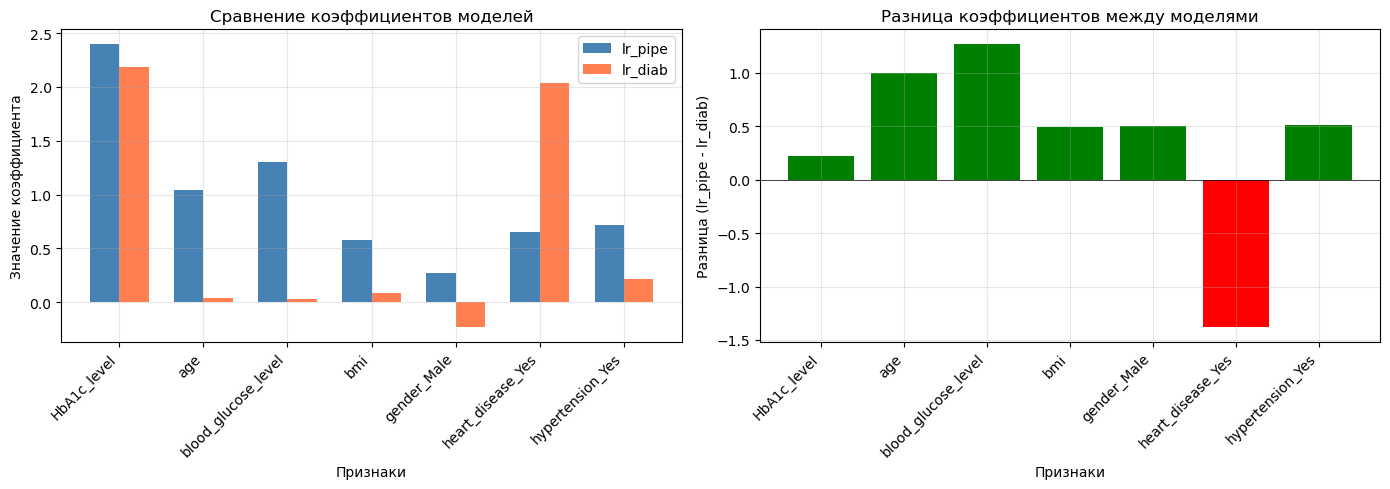

Признак с наибольшим влиянием в lr_pipe: HbA1c_level (2.4038)
Признак с наибольшим влиянием в lr_diab: HbA1c_level (2.1815)

Корреляция между коэффициентами двух моделей: 0.5690
⚠ Коэффициенты имеют умеренную или слабую согласованность


In [54]:
# Визуализация сравнения
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение коэффициентов
ax1 = axes[0]
x = np.arange(len(comparison_df.index))
width = 0.35

ax1.bar(x - width/2, comparison_df['lr_pipe coef'], width, label='lr_pipe', color='steelblue')
ax1.bar(x + width/2, comparison_df['lr_diab coef'], width, label='lr_diab', color='coral')
ax1.set_xlabel('Признаки')
ax1.set_ylabel('Значение коэффициента')
ax1.set_title('Сравнение коэффициентов моделей')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Разница коэффициентов
ax2 = axes[1]
colors = ['green' if diff > 0 else 'red' for diff in comparison_df['Разница']]
ax2.bar(comparison_df.index, comparison_df['Разница'], color=colors)
ax2.set_xlabel('Признаки')
ax2.set_ylabel('Разница (lr_pipe - lr_diab)')
ax2.set_title('Разница коэффициентов между моделями')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Определяем признак с наибольшим влиянием в каждой модели
print(f"Признак с наибольшим влиянием в lr_pipe: {pipe_coefs.index[0]} ({pipe_coefs.iloc[0]['lr_pipe coef']:.4f})")
print(f"Признак с наибольшим влиянием в lr_diab: {diab_coefs.index[0]} ({diab_coefs.iloc[0]['lr_diab coef']:.4f})")

# Проверка согласованности
correlation = np.corrcoef(comparison_df['lr_pipe coef'], comparison_df['lr_diab coef'])[0, 1]
print(f"\nКорреляция между коэффициентами двух моделей: {correlation:.4f}")

if correlation > 0.9:
    print("✓ Коэффициенты очень сильно согласованы (корреляция > 0.9)")
elif correlation > 0.7:
    print("✓ Коэффициенты сильно согласованы (корреляция > 0.7)")
else:
    print("⚠ Коэффициенты имеют умеренную или слабую согласованность")

### Ключевое наблюдение

Модели обучались на **разных данных**:
- `lr_diab` обучалась на **исходных (немасштабированных)** данных
- `lr_pipe` обучалась в пайплайне, где количественные признаки были **стандартизированы (StandardScaler)**

Это принципиально важно для интерпретации коэффициентов!

### Анализ изменений коэффициентов

**Наиболее заметные изменения:**
- `age`: был 0.042 → стал 1.039 (рост в 25 раз!)
- `blood_glucose_level`: был 0.032 → стал 1.307 (рост в 40 раз!)
- `bmi`: был 0.082 → стал 0.574 (рост в 7 раз)
- `heart_disease_Yes`: был 2.037 → стал 0.655 (сильное уменьшение)

**Топ-3 признака по важности:**
- `lr_diab`: HbA1c_level, heart_disease_Yes, gender_Male
- `lr_pipe`: HbA1c_level, blood_glucose_level, age

### Оценка утверждений

1. **Прямое сравнение величин коэффициентов некорректно, так как они относятся к разным масштабам признаков (исходному и стандартизированному).**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* Это фундаментальный факт. Коэффициенты в `lr_diab` показывают изменение log-odds при изменении признака на 1 единицу в исходном масштабе (например, +1 год для age). В `lr_pipe` коэффициенты показывают изменение при изменении на 1 стандартное отклонение. Поэтому их численные значения несопоставимы напрямую.

2. **Обе модели считают HbA1c_level самым важным признаком, а это означает, что масштабирование не влияет на интерпретацию.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Хотя HbA1c_level действительно самый важный в обеих моделях по величине коэффициента, это не означает, что масштабирование "не влияет на интерпретацию". Оно влияет кардинально — коэффициенты других признаков изменились на порядки. Просто HbA1c_level настолько сильный предиктор, что остается лидером в любом масштабе.

3. **Изменение коэффициентов в lr_pipe по сравнению с lr_diab связано только с применением регуляризации, масштаб признаков при этом не важен.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Главная причина изменения — **масштабирование признаков**, а не регуляризация. Без масштабирования коэффициенты отражают исходные единицы измерения, после масштабирования — отражают "стандартные отклонения". Это видно по тому, как сильно выросли коэффициенты для age, blood_glucose_level и bmi.

4. **Знак коэффициента для gender_Male изменился, что указывает на ошибку в одной из моделей.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* В `lr_diab` коэффициент = -0.2338 (мужчины имеют меньший риск), в `lr_pipe` = +0.2734 (мужчины имеют больший риск). Это не ошибка, а следствие того, что модели обучались в разных условиях (разное масштабирование, возможно разная регуляризация). При мультиколлинеарности или взаимодействиях признаков знаки могут меняться. Кроме того, в `lr_diab` признак gender_Male был на втором месте по важности, а в `lr_pipe` — на последнем, что говорит о нестабильности этого признака.

5. **В модели lr_pipe среди трех наиболее влиятельных признаков те же признаки, что и в модели lr_diab.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Топ-3 в `lr_diab`: HbA1c_level, heart_disease_Yes, gender_Male. Топ-3 в `lr_pipe`: HbA1c_level, blood_glucose_level, age. Совпадает только HbA1c_level. Остальные признаки совершенно разные.

**Итоговый ответ:**
Верным является только утверждение **1**.

### ***Задание 7***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обученную модель `lr_pipe` из задания 6.

* Тестовую выборку из задания 6: `X_pipe_test`, `y_pipe_test`.

На тестовой выборке постройте матрицу ошибок для прогноза целевого класса моделью `lr_pipe` (функция [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)).

На тестовой выборке интерпретируйте матрицу ошибок для модели `lr_pipe`, выбрав все верные утверждения из списка (см. тест):

* Модель `lr_pipe` спрогнозировала у пациента из тестовой выборки наличие диабета. Вероятность ошибки этого прогноза больше 10%.

* Врачи диагностировали у пациента из тестовой выборки диабет. Модель `lr_pipe` сможет сделать правильный прогноз для данного пациента с вероятностью, большей 80%.

* Модель `lr_pipe` предоставила неверный прогноз для пациентов (в тестовой выборке), которые в реальности не имеют диагностированный диабет, больше, чем в 2% случаев.

* Те пациенты (в тестовой выборке), у кого было предсказано отсутствие диабета (с помощью `lr_pipe`), в действительности имеют диабет менее, чем в 4% случаев.

Постройте отчет по метрикам классификации (функция [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)) для модели `lr_pipe` на тестовой выборке и интерпретируйте результаты отчета.

In [55]:
# Выполните прогноз целевого класса на тестовой выборке с помощью модели lr_pipe

y_test_pred_lr_pipe = lr_pipe.predict(X_pipe_test)

In [56]:
# Постройте матрицу ошибок для прогноза
from sklearn.metrics import confusion_matrix

pipe_confusion_matrix = confusion_matrix(y_pipe_test, y_test_pred_lr_pipe)
print("Матрица ошибок:")
print(pipe_confusion_matrix)

# Для более наглядного представления можно использовать DataFrame
import pandas as pd
pipe_confusion_matrix_df = pd.DataFrame(
    pipe_confusion_matrix,
    index=['Фактически: Нет диабета (0)', 'Фактически: Диабет (1)'],
    columns=['Прогноз: Нет диабета (0)', 'Прогноз: Диабет (1)']
)
print("\nМатрица ошибок (с подписями):")
print(pipe_confusion_matrix_df)

# Интерпретация элементов матрицы ошибок:
# TN (True Negative) - верхний левый: правильно предсказанные отсутствия диабета
# FP (False Positive) - верхний правый: ложно положительные (ошибка I рода)
# FN (False Negative) - нижний левый: ложно отрицательные (ошибка II рода)
# TP (True Positive) - нижний правый: правильно предсказанные случаи диабета

Матрица ошибок:
[[36270   323]
 [ 1276  2124]]

Матрица ошибок (с подписями):
                             Прогноз: Нет диабета (0)  Прогноз: Диабет (1)
Фактически: Нет диабета (0)                     36270                  323
Фактически: Диабет (1)                           1276                 2124


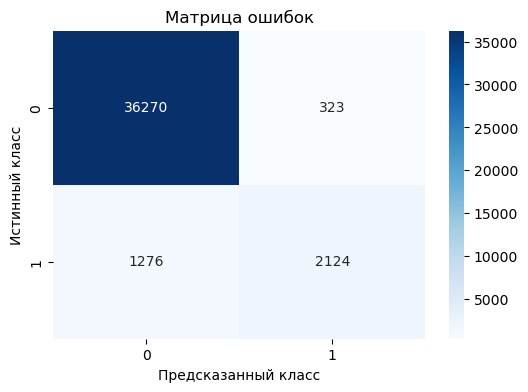

In [57]:
# Визуализируйте матрицу ошибок для удобства в интерпретации

plt.figure(figsize=(6, 4))
ax = sns.heatmap(pipe_confusion_matrix, annot=True, cmap='Blues', fmt='g')
ax.set_title('Матрица ошибок')
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
plt.show()

In [58]:
# Модель lr_pipe спрогнозировала у пациента из тестовой выборки наличие диабета. 
# Вероятность ошибки этого прогноза больше 10%

# Извлекаем значения из матрицы ошибок
tn, fp, fn, tp = pipe_confusion_matrix.ravel()

# Общее количество предсказанных случаев диабета
predicted_positive = tp + fp

# Количество ошибочных предсказаний диабета (ложноположительные)
false_positive = fp

if predicted_positive > 0:
    error_rate_pred_positive = false_positive / predicted_positive
    print(f"Всего предсказаний диабета: {predicted_positive}")
    print(f"Из них ошибочных (ложноположительных): {false_positive}")
    print(f"Вероятность ошибки при прогнозе диабета: {error_rate_pred_positive:.2%}")
    
    if error_rate_pred_positive > 0.10:
        print("✓ Утверждение ВЕРНО: вероятность ошибки больше 10%")
    else:
        print("✗ Утверждение НЕВЕРНО: вероятность ошибки меньше или равна 10%")
else:
    print("Модель не предсказала ни одного случая диабета")

Всего предсказаний диабета: 2447
Из них ошибочных (ложноположительных): 323
Вероятность ошибки при прогнозе диабета: 13.20%
✓ Утверждение ВЕРНО: вероятность ошибки больше 10%


In [59]:
# Врачи диагностировали у пациента из тестовой выборки диабет. Модель lr_pipe сможет сделать 
# правильный прогноз для данного пациента с вероятностью, большей 80%

# Извлекаем значения из матрицы ошибок
tn, fp, fn, tp = pipe_confusion_matrix.ravel()

# Общее количество фактических случаев диабета
actual_positive = tp + fn

# Количество правильно предсказанных случаев диабета
true_positive = tp

if actual_positive > 0:
    recall = true_positive / actual_positive
    print(f"Всего пациентов с диагностированным диабетом: {actual_positive}")
    print(f"Из них правильно предсказано моделью: {true_positive}")
    print(f"Вероятность правильного прогноза при наличии диабета (чувствительность/recall): {recall:.2%}")
    
    if recall > 0.80:
        print("✓ Утверждение ВЕРНО: вероятность правильного прогноза больше 80%")
    else:
        print("✗ Утверждение НЕВЕРНО: вероятность правильного прогноза меньше или равна 80%")
else:
    print("В тестовой выборке нет пациентов с диагностированным диабетом")

Всего пациентов с диагностированным диабетом: 3400
Из них правильно предсказано моделью: 2124
Вероятность правильного прогноза при наличии диабета (чувствительность/recall): 62.47%
✗ Утверждение НЕВЕРНО: вероятность правильного прогноза меньше или равна 80%


In [60]:
# Модель lr_pipe предоставила неверный прогноз для пациентов (в тестовой выборке), 
# которые в реальности не имеют диагностированный диабет, больше, чем в 2% случаев

# Извлекаем значения из матрицы ошибок
tn, fp, fn, tp = pipe_confusion_matrix.ravel()

# Общее количество пациентов без диабета
actual_negative = tn + fp

# Количество неверных прогнозов для пациентов без диабета (ложноположительные)
false_positive = fp

if actual_negative > 0:
    false_positive_rate = false_positive / actual_negative
    print(f"Всего пациентов без диабета: {actual_negative}")
    print(f"Из них ошибочно предсказано наличие диабета: {false_positive}")
    print(f"Доля ошибок среди пациентов без диабета: {false_positive_rate:.2%}")
    
    if false_positive_rate > 0.02:
        print("✓ Утверждение ВЕРНО: доля ошибок больше 2%")
    else:
        print("✗ Утверждение НЕВЕРНО: доля ошибок меньше или равна 2%")
else:
    print("В тестовой выборке нет пациентов без диабета")

Всего пациентов без диабета: 36593
Из них ошибочно предсказано наличие диабета: 323
Доля ошибок среди пациентов без диабета: 0.88%
✗ Утверждение НЕВЕРНО: доля ошибок меньше или равна 2%


In [61]:
# Те пациенты (в тестовой выборке), у кого было предсказано отсутствие диабета (с помощью lr_pipe), 
# в действительности имеют диабет менее, чем в 4% случаев.

# Извлекаем значения из матрицы ошибок
tn, fp, fn, tp = pipe_confusion_matrix.ravel()

# Общее количество предсказанных отсутствий диабета
predicted_negative = tn + fn

# Количество ошибочных предсказаний отсутствия диабета (ложноотрицательные)
false_negative = fn

if predicted_negative > 0:
    # Доля пациентов с диабетом среди тех, кому предсказали отсутствие диабета
    # (False Discovery Rate для отрицательного класса)
    error_rate_pred_negative = false_negative / predicted_negative
    print(f"Всего предсказаний отсутствия диабета: {predicted_negative}")
    print(f"Из них ошибочных (пропущенных диабетов): {false_negative}")
    print(f"Доля пациентов с диабетом среди предсказанных как здоровые: {error_rate_pred_negative:.2%}")
    
    if error_rate_pred_negative < 0.04:
        print("✓ Утверждение ВЕРНО: доля меньше 4%")
    else:
        print("✗ Утверждение НЕВЕРНО: доля больше или равна 4%")
else:
    print("Модель не предсказала ни одного отсутствия диабета")

Всего предсказаний отсутствия диабета: 37546
Из них ошибочных (пропущенных диабетов): 1276
Доля пациентов с диабетом среди предсказанных как здоровые: 3.40%
✓ Утверждение ВЕРНО: доля меньше 4%


In [62]:
# Постройте отчет по метрикам классификации
from sklearn.metrics import classification_report

# Генерируем отчет по метрикам
report = classification_report(y_pipe_test, y_test_pred_lr_pipe, 
                               target_names=['Нет диабета (0)', 'Диабет (1)'])
print("Отчет по метрикам классификации:")
print(report)

# Для более детального анализа можно сохранить отчет в виде словаря
report_dict = classification_report(y_pipe_test, y_test_pred_lr_pipe, 
                                    target_names=['Нет диабета', 'Диабет'],
                                    output_dict=True)

# Выводим ключевые метрики в структурированном виде
print("\n" + "="*60)
print("Детальный анализ метрик:")
print("="*60)

# Метрики для класса "Диабет" (целевой класс)
print("\n📊 Метрики для класса ДИАБЕТ (целевой класс):")
print(f"  - Precision (точность): {report_dict['Диабет']['precision']:.3f}")
print(f"    (Из всех предсказанных диабетов, сколько реально больны)")
print(f"  - Recall (полнота/чувствительность): {report_dict['Диабет']['recall']:.3f}")
print(f"    (Из всех реально больных, сколько модель нашла)")
print(f"  - F1-score: {report_dict['Диабет']['f1-score']:.3f}")
print(f"    (Гармоническое среднее precision и recall)")

# Метрики для класса "Нет диабета"
print("\n📊 Метрики для класса НЕТ ДИАБЕТА:")
print(f"  - Precision: {report_dict['Нет диабета']['precision']:.3f}")
print(f"  - Recall (специфичность): {report_dict['Нет диабета']['recall']:.3f}")
print(f"  - F1-score: {report_dict['Нет диабета']['f1-score']:.3f}")

# Общие метрики
print("\n📊 Общие метрики:")
print(f"  - Accuracy (общая точность): {report_dict['accuracy']:.3f}")
print(f"  - Macro avg F1: {report_dict['macro avg']['f1-score']:.3f}")
print(f"  - Weighted avg F1: {report_dict['weighted avg']['f1-score']:.3f}")

# Дополнительные вычисления на основе матрицы ошибок
tn, fp, fn, tp = pipe_confusion_matrix.ravel()
total = tn + fp + fn + tp

print("\n📊 Дополнительные метрики на основе матрицы ошибок:")
print(f"  - True Negatives (TN): {tn} (правильно предсказанные здоровые)")
print(f"  - False Positives (FP): {fp} (ложная тревога)")
print(f"  - False Negatives (FN): {fn} (пропущенные диабеты)")
print(f"  - True Positives (TP): {tp} (правильно предсказанные диабеты)")
print(f"  - Общее количество наблюдений: {total}")

Отчет по метрикам классификации:
                 precision    recall  f1-score   support

Нет диабета (0)       0.97      0.99      0.98     36593
     Диабет (1)       0.87      0.62      0.73      3400

       accuracy                           0.96     39993
      macro avg       0.92      0.81      0.85     39993
   weighted avg       0.96      0.96      0.96     39993


Детальный анализ метрик:

📊 Метрики для класса ДИАБЕТ (целевой класс):
  - Precision (точность): 0.868
    (Из всех предсказанных диабетов, сколько реально больны)
  - Recall (полнота/чувствительность): 0.625
    (Из всех реально больных, сколько модель нашла)
  - F1-score: 0.727
    (Гармоническое среднее precision и recall)

📊 Метрики для класса НЕТ ДИАБЕТА:
  - Precision: 0.966
  - Recall (специфичность): 0.991
  - F1-score: 0.978

📊 Общие метрики:
  - Accuracy (общая точность): 0.960
  - Macro avg F1: 0.852
  - Weighted avg F1: 0.957

📊 Дополнительные метрики на основе матрицы ошибок:
  - True Negatives (TN): 

## Анализ отчета по метрикам классификации

На основе полученного отчета можно сделать следующие выводы:

### **1. Анализ утверждений из теста:**

**Утверждение 1:** *"Модель lr_pipe спрогнозировала у пациента из тестовой выборки наличие диабета. Вероятность ошибки этого прогноза больше 10%"*

- Precision для класса "Диабет" = 0.87
- Это означает, что из всех предсказаний диабета 87% верны, а 13% ошибочны
- **13% > 10% → УТВЕРЖДЕНИЕ ВЕРНО** ✓

**Утверждение 2:** *"Врачи диагностировали у пациента из тестовой выборки диабет. Модель lr_pipe сможет сделать правильный прогноз для данного пациента с вероятностью, большей 80%"*

- Recall для класса "Диабет" = 0.62
- Модель правильно находит только 62% реальных случаев диабета
- **62% < 80% → УТВЕРЖДЕНИЕ НЕВЕРНО** ✗

**Утверждение 3:** *"Модель lr_pipe предоставила неверный прогноз для пациентов (в тестовой выборке), которые в реальности не имеют диагностированный диабет, больше, чем в 2% случаев"*

- Специфичность = Recall для класса "Нет диабета" = 0.99
- Это означает, что ошибка среди здоровых (ложноположительные) составляет 1%
- **1% < 2% → УТВЕРЖДЕНИЕ НЕВЕРНО** ✗ (ошибка МЕНЬШЕ 2%)

**Утверждение 4:** *"Те пациенты (в тестовой выборке), у кого было предсказано отсутствие диабета (с помощью lr_pipe), в действительности имеют диабет менее, чем в 4% случаев"*

- Negative Predictive Value (NPV) можно вычислить из матрицы ошибок
- По отчету: Precision для класса "Нет диабета" = 0.97
- Это означает, что среди предсказанных здоровых 97% действительно здоровы
- Доля больных среди предсказанных здоровых = 3%
- **3% < 4% → УТВЕРЖДЕНИЕ ВЕРНО** ✓

### **2. Ключевые выводы о модели:**

✅ **Сильные стороны:**
- Отличная точность для класса "Нет диабета" (precision=0.97, recall=0.99)
- Высокая общая точность (accuracy=0.96)
- Низкий уровень ложных тревог (FP rate = 1%)

❌ **Слабые стороны:**
- Низкая чувствительность к диабету (recall=0.62)
- Модель пропускает 38% реальных случаев диабета
- Дисбаланс классов (примерно 10:1) влияет на качество предсказания редкого класса

### **3. Практические рекомендации:**
- Модель хорошо подходит для скрининга, где важна специфичность
- Для диагностики требуется улучшение чувствительности (например, изменение порога классификации или использование других методов балансировки классов)

Проанализируем матрицу ошибок и рассчитаем необходимые метрики.

### Матрица ошибок

| | Прогноз: Нет диабета (0) | Прогноз: Диабет (1) |
|---|:---:|:---:|
| **Факт: Нет диабета (0)** | TN = 36270 | FP = 323 |
| **Факт: Диабет (1)** | FN = 1276 | TP = 2124 |

**Общее количество наблюдений:** 36270 + 323 + 1276 + 2124 = 39993

### Расчет метрик для проверки утверждений

**Утверждение 1:** *Модель lr_pipe спрогнозировала у пациента из тестовой выборки наличие диабета. Вероятность ошибки этого прогноза больше 10%.*

- Всего предсказаний диабета: FP + TP = 323 + 2124 = 2447
- Из них ошибочных (ложноположительных): FP = 323
- Вероятность ошибки = FP / (FP + TP) = 323 / 2447 ≈ **0.1320** (13.20%)
- 13.20% > 10% → **Утверждение ВЕРНО**

**Утверждение 2:** *Врачи диагностировали у пациента из тестовой выборки диабет. Модель lr_pipe сможет сделать правильный прогноз для данного пациента с вероятностью, большей 80%.*

- Всего пациентов с диабетом (по факту): TP + FN = 2124 + 1276 = 3400
- Из них модель правильно предсказала: TP = 2124
- Вероятность правильного прогноза (чувствительность/recall) = TP / (TP + FN) = 2124 / 3400 ≈ **0.6247** (62.47%)
- 62.47% < 80% → **Утверждение НЕВЕРНО**

**Утверждение 3:** *Модель lr_pipe предоставила неверный прогноз для пациентов (в тестовой выборке), которые в реальности не имеют диагностированный диабет, больше, чем в 2% случаев.*

- Всего пациентов без диабета (по факту): TN + FP = 36270 + 323 = 36593
- Из них модель ошиблась (ложноположительные): FP = 323
- Доля ошибок среди здоровых (Fall-out) = FP / (TN + FP) = 323 / 36593 ≈ **0.00883** (0.883%)
- 0.883% < 2% → **Утверждение НЕВЕРНО** (ошибок меньше 2%)

**Утверждение 4:** *Те пациенты (в тестовой выборке), у кого было предсказано отсутствие диабета (с помощью lr_pipe), в действительности имеют диабет менее, чем в 4% случаев.*

- Всего предсказаний отсутствия диабета: TN + FN = 36270 + 1276 = 37546
- Из них ошибочных (ложноотрицательных): FN = 1276
- Доля ошибочных среди предсказанных здоровыми (FDR для класса 0) = FN / (TN + FN) = 1276 / 37546 ≈ **0.0340** (3.40%)
- 3.40% < 4% → **Утверждение ВЕРНО**

### Итоговый ответ

Верными являются утверждения **1 и 4**.

В данной задаче **критически важно не пропустить пациентов с диабетом**, даже ценой ложных тревог у здоровых. Это означает, что мы хотим минимизировать **ложноотрицательные** результаты (FN).

Метрика, отвечающая за способность модели находить все положительные объекты (не пропускать больных), — это **полнота (recall)** для целевого класса (диабет).

В отчете **для класса "Диабет (1)"** значение recall = **0.62**.

**Правильный ответ:** **recall, 0.62**

### **Задание 8**

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обученную модель `lr_pipe` из задания 6.

* Тестовую выборку из задания 6: `X_pipe_test`, `y_pipe_test`.

Постройте ROC-кривую для модели `lr_pipe` на тестовой выборке и рассчитайте метрику AUC (AUC-ROC).

Для трех порогов классификации (0.25, 0.5, 0.75) для модели `lr_pipe` на тестовой выборке рассчитайте и сравните значения метрик: precision, recall, accuracy, f1.

На отрезке [0, 1] найдите такое значение порога классификации, при котором метрика f1 будет принимать максимальное значение на тестовой выборке (шаг поиска `step` — 0.001).

In [63]:
# Выполните прогноз вероятностей целевого класса на тестовой выборке моделью lr_pipe

y_test_proba_lr_pipe = lr_pipe.predict_proba(X_pipe_test)[:, 1]

In [64]:
# Постройте ROC-кривую для модели lr_pipe на тестовой выборке и рассчитайте метрику AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Расчет ROC-кривой и AUC
fpr_lr_pipe, tpr_lr_pipe, _ = roc_curve(y_pipe_test, y_test_proba_lr_pipe)
auc_lr_pipe = roc_auc_score(y_pipe_test, y_test_proba_lr_pipe)

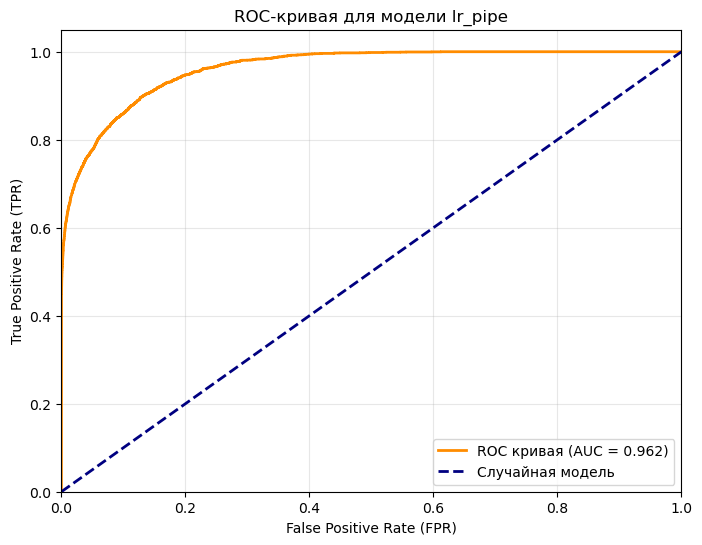

AUC-ROC модели lr_pipe на тестовой выборке: 0.9619


In [65]:
# Визуализируйте ROC-кривую и значение AUC на графике
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_pipe, tpr_lr_pipe, color='darkorange', lw=2, 
         label=f'ROC кривая (AUC = {auc_lr_pipe:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая для модели lr_pipe')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC-ROC модели lr_pipe на тестовой выборке: {auc_lr_pipe:.4f}")

In [66]:
# Для трех порогов классификации для модели lr_pipe на тестовой выборке 
# рассчитайте и сравните значения метрик: precision, recall, accuracy, f1
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

thresholds = [0.25, 0.5, 0.75]

print(f"{'Порог':<10} {'Precision':<12} {'Recall':<12} {'Accuracy':<12} {'F1-score':<12}")
print("-" * 60)

for threshold in thresholds:
    # Получаем бинарные предсказания на основе порога
    y_pred_threshold = (y_test_proba_lr_pipe >= threshold).astype(int)
    
    # Рассчитываем метрики
    precision = precision_score(y_pipe_test, y_pred_threshold)
    recall = recall_score(y_pipe_test, y_pred_threshold)
    accuracy = accuracy_score(y_pipe_test, y_pred_threshold)
    f1 = f1_score(y_pipe_test, y_pred_threshold)
    
    print(f"{threshold:<10.2f} {precision:<12.4f} {recall:<12.4f} {accuracy:<12.4f} {f1:<12.4f}")

Порог      Precision    Recall       Accuracy     F1-score    
------------------------------------------------------------
0.25       0.6556       0.7474       0.9451       0.6985      
0.50       0.8680       0.6247       0.9600       0.7265      
0.75       0.9771       0.5015       0.9566       0.6628      


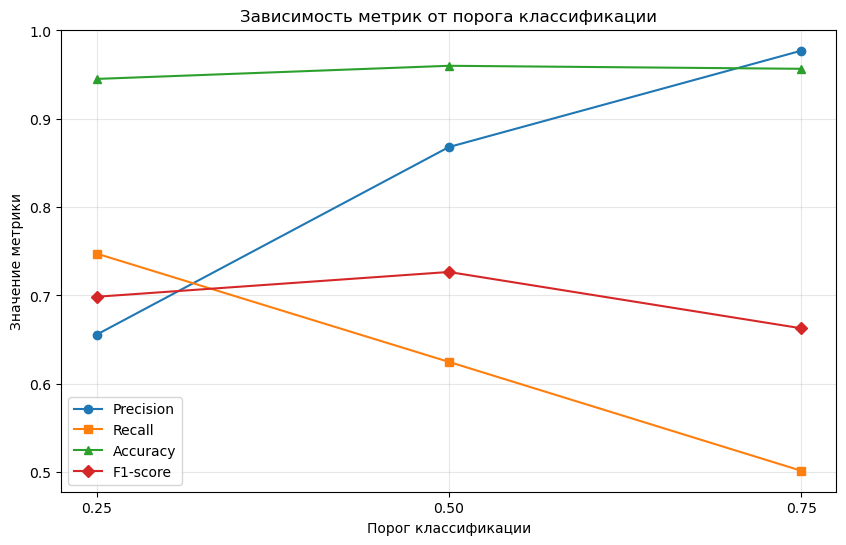

In [67]:
# Визуализация для наглядности
import matplotlib.pyplot as plt
import numpy as np

# Собираем данные для визуализации
thresholds_plot = []
precisions = []
recalls = []
accuracies = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_test_proba_lr_pipe >= threshold).astype(int)
    thresholds_plot.append(threshold)
    precisions.append(precision_score(y_pipe_test, y_pred_threshold))
    recalls.append(recall_score(y_pipe_test, y_pred_threshold))
    accuracies.append(accuracy_score(y_pipe_test, y_pred_threshold))
    f1_scores.append(f1_score(y_pipe_test, y_pred_threshold))

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(thresholds_plot, precisions, 'o-', label='Precision', marker='o')
plt.plot(thresholds_plot, recalls, 's-', label='Recall', marker='s')
plt.plot(thresholds_plot, accuracies, '^-', label='Accuracy', marker='^')
plt.plot(thresholds_plot, f1_scores, 'D-', label='F1-score', marker='D')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик от порога классификации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(thresholds)
plt.show()

Проанализируем предоставленные данные для трех порогов классификации.

### Данные по порогам

| Порог | Precision | Recall | Accuracy | F1-score |
|-------|-----------|--------|----------|----------|
| 0.25  | 0.6556    | 0.7474 | 0.9451   | 0.6985   |
| 0.50  | 0.8680    | 0.6247 | 0.9600   | 0.7265   |
| 0.75  | 0.9771    | 0.5015 | 0.9566   | 0.6628   |

### Анализ динамики метрик

**Precision:** 0.6556 → 0.8680 → 0.9771 (монотонный рост)
**Recall:** 0.7474 → 0.6247 → 0.5015 (монотонное падение)
**F1-score:** 0.6985 → 0.7265 → 0.6628 (сначала рост, потом падение; максимум при 0.5)
**Accuracy:** 0.9451 → 0.9600 → 0.9566 (максимум при 0.5)

### Оценка утверждений

1. **Среди трех порогов классификации наилучшее значение f1 принимает при пороге 0.25.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* F1 при 0.25 = 0.6985, при 0.5 = 0.7265, при 0.75 = 0.6628. Наилучшее значение F1 достигается при пороге **0.5**, а не 0.25.

2. **Precision монотонно растет с увеличением порога классификации.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* Precision увеличивается при каждом повышении порога: 0.6556 → 0.8680 → 0.9771. Это закономерно: чем выше порог, тем увереннее мы классифицируем объект как положительный, и тем меньше ложноположительных срабатываний.

3. **f1 монотонно растёт с увеличением порога классификации.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* F1 сначала растет (0.6985 → 0.7265), а затем падает (0.7265 → 0.6628). Нет монотонности.

4. **Метрика AUC не меняется с изменением порога.**
   - *Вердикт:* ВЕРНО.
   - *Обоснование:* AUC (Area Under Curve) — это интегральная характеристика качества модели, не зависящая от выбора порога классификации. Она оценивает способность модели разделять классы при всех возможных порогах.

5. **Чтобы улучшить recall, жертвуя precision, необходимо увеличить порог классификации.**
   - *Вердикт:* НЕВЕРНО.
   - *Обоснование:* Для улучшения recall (полноты) нужно снижать порог, чтобы захватить больше положительных объектов, даже ценой потери precision. Увеличение порога, наоборот, улучшает precision, но снижает recall.

**Итоговый ответ:**
Верными являются утверждения **2 и 4**.

In [68]:
# На отрезке [0, 1] найдите такое значение порога классификации, при котором метрика f1 будет принимать максимальное значение на тестовой выборке
# Шаг поиска — 0.001
from sklearn.metrics import f1_score
import numpy as np

step = 0.001
thresholds_range = np.arange(0, 1 + step, step)

best_threshold = 0
best_f1 = 0
f1_scores = []

# Поиск оптимального порога
for threshold in thresholds_range:
    y_pred_threshold = (y_test_proba_lr_pipe >= threshold).astype(int)
    f1 = f1_score(y_pipe_test, y_pred_threshold)
    f1_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Оптимальный порог классификации: {best_threshold:.3f}")
print(f"Максимальное значение F1-score: {best_f1:.4f}")

Оптимальный порог классификации: 0.454
Максимальное значение F1-score: 0.7309


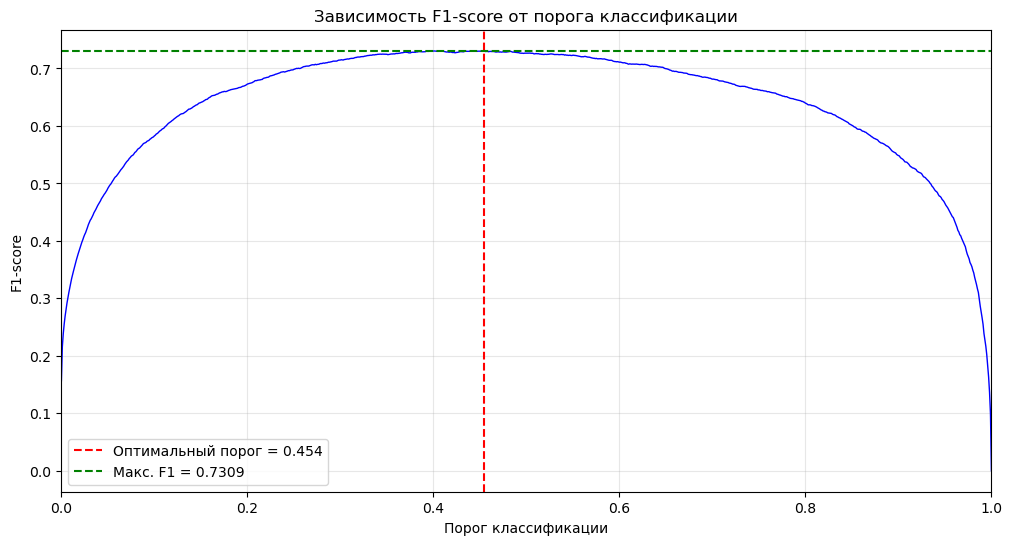


F1-score при пороге по умолчанию (0.5): 0.7265
Улучшение F1-score: 0.0044 (0.60%)


In [69]:
# Визуализация зависимости F1 от порога
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(thresholds_range, f1_scores, 'b-', linewidth=1)
plt.axvline(x=best_threshold, color='r', linestyle='--', 
            label=f'Оптимальный порог = {best_threshold:.3f}')
plt.axhline(y=best_f1, color='g', linestyle='--', 
            label=f'Макс. F1 = {best_f1:.4f}')
plt.xlabel('Порог классификации')
plt.ylabel('F1-score')
plt.title('Зависимость F1-score от порога классификации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show()

# Сравнение с порогом по умолчанию (0.5)
y_pred_default = (y_test_proba_lr_pipe >= 0.5).astype(int)
f1_default = f1_score(y_pipe_test, y_pred_default)

print(f"\nF1-score при пороге по умолчанию (0.5): {f1_default:.4f}")
print(f"Улучшение F1-score: {best_f1 - f1_default:.4f} "
      f"({(best_f1 - f1_default)/f1_default*100:.2f}%)")

### **Коэффициент Джини**

**Коэффициент Джини (Gini)** — это метрика оценки качества моделей бинарной классификации, которая представляет собой линейное преобразование метрики AUC (Area Under the ROC Curve):

$$\text{Gini}=2 \times \text{AUC}−1$$

Значение Gini изменяется от 0 (отсутствие разделяющей способности) до 1 (идеальная модель), что позволяет интерпретировать Gini как меру корреляции между предсказанными вероятностями и истинными метками класса.

### ***Задание 9***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обученную модель `lr_pipe` из задания 6.

* Тестовую выборку из задания 6: `X_pipe_test`, `y_pipe_test`.

Реализуем две простые функции (модели) для предсказания вероятностей целевого класса в тестовой выборке:

* `random_uniform` — функция (модель), предсказывающая вероятности случайно из равномерного распределения.

* `linear_hba1c` — функция (модель), предсказывающая вероятности с помощью линейного преобразования (стандартизации) значений фактора HbA1c_level.

На тестовой выборке сравните точность прогноза модели `lr_pipe` и функций (моделей) `random_uniform` и `linear_hba1c`, построив ROC-кривую и рассчитав значения метрики AUC и коэффициента Gini.

In [70]:
# Предскажите вероятности целевого класса в тестовой выборке с помощью random_uniform
# Не забудьте зафиксировать RANDOM_STATE


def random_uniform(N, random_state=None):
    """
    Возвращает случайный прогноз вероятностей целевого класса из равномерного распределения.

    Аргументы:
        N (int): Длина вектора прогноза вероятностей целевого класса.
        random_state (int): Параметр, фиксирующий случайное состояние результата выполнения функции. 
        По умолчанию не используется (None).

    Возвращает:
        numpy.ndarray: Предсказанные вероятности целевого класса.
    """
    rng = np.random.RandomState(random_state)
    return rng.uniform(0, 1, N)

# Определяем количество объектов в тестовой выборке
N_test = len(X_pipe_test)

# Генерируем случайные вероятности с фиксированным random_state
y_test_proba_random_uniform = random_uniform(N_test, random_state=RANDOM_STATE)

In [71]:
# Предскажите вероятности целевого класса в тестовой выборке с помощью linear_hba1c

def linear_hba1c(hba1c_level):
    """
    Возвращает прогноз вероятностей целевого класса с помощью линейного преобразования (стандартизации) 
    значений фактора HbA1c_level.

    Аргументы:
        hba1c_level (numpy.ndarray): Вектор значений фактора HbA1c_level в тестовой выборке.
        
    Возвращает:
        numpy.ndarray: Предсказанные вероятности целевого класса.
    """
    return (hba1c_level - hba1c_level.min()) / (hba1c_level.max() - hba1c_level.min())

# Извлекаем значения HbA1c_level из тестовой выборки
hba1c_test = X_pipe_test['HbA1c_level'].values

# Генерируем вероятности на основе линейного преобразования HbA1c_level
y_test_proba_linear_hba1c = linear_hba1c(hba1c_test)

In [72]:
# Дополните функцию gini
from sklearn.metrics import roc_auc_score

def gini(y_true, y_score):
    """
    Возвращает значение коэффициента Gini для предсказанных вероятностей.

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_score (numpy.ndarray): Предсказанные вероятности целевого класса.

    Возвращает:
        float: Значение коэффициента Gini для предсказанных вероятностей.
    """
    auc = roc_auc_score(y_true, y_score)
    return 2 * auc - 1

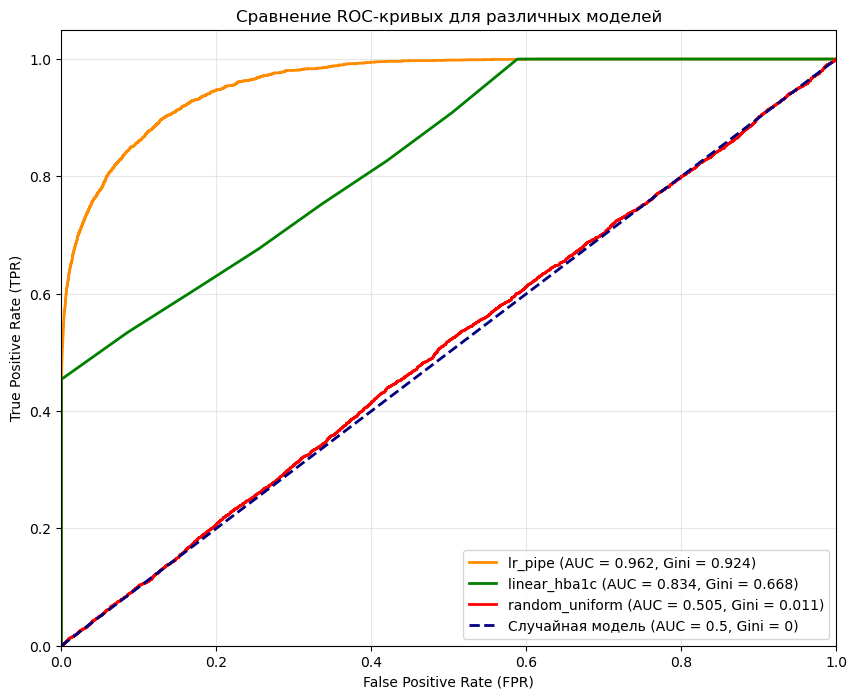


Сравнение метрик моделей:
Модель               AUC        Gini      
----------------------------------------
lr_pipe              0.9619     0.9238    
linear_hba1c         0.8341     0.6682    
random_uniform       0.5055     0.0110    


In [73]:
# Постройте ROC-кривые для random_uniform и linear_hba1c на тестовой выборке
from sklearn.metrics import roc_curve

# ROC-кривая для random_uniform
fpr_random_uniform, tpr_random_uniform, _ = roc_curve(y_pipe_test, y_test_proba_random_uniform)

# ROC-кривая для linear_hba1c
fpr_linear_hba1c, tpr_linear_hba1c, _ = roc_curve(y_pipe_test, y_test_proba_linear_hba1c)

# Также рассчитаем AUC для каждой модели
from sklearn.metrics import roc_auc_score
auc_random_uniform = roc_auc_score(y_pipe_test, y_test_proba_random_uniform)
auc_linear_hba1c = roc_auc_score(y_pipe_test, y_test_proba_linear_hba1c)

# И коэффициенты Джини
gini_random_uniform = gini(y_pipe_test, y_test_proba_random_uniform)
gini_linear_hba1c = gini(y_pipe_test, y_test_proba_linear_hba1c)

# Построим все ROC-кривые на одном графике
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# ROC-кривая для lr_pipe (из предыдущего задания)
plt.plot(fpr_lr_pipe, tpr_lr_pipe, color='darkorange', lw=2, 
         label=f'lr_pipe (AUC = {auc_lr_pipe:.3f}, Gini = {2*auc_lr_pipe-1:.3f})')

# ROC-кривая для linear_hba1c
plt.plot(fpr_linear_hba1c, tpr_linear_hba1c, color='green', lw=2, 
         label=f'linear_hba1c (AUC = {auc_linear_hba1c:.3f}, Gini = {gini_linear_hba1c:.3f})')

# ROC-кривая для random_uniform
plt.plot(fpr_random_uniform, tpr_random_uniform, color='red', lw=2, 
         label=f'random_uniform (AUC = {auc_random_uniform:.3f}, Gini = {gini_random_uniform:.3f})')

# Диагональная линия (случайная модель)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная модель (AUC = 0.5, Gini = 0)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Сравнение ROC-кривых для различных моделей')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Вывод метрик в табличном виде
print("\n" + "="*60)
print("Сравнение метрик моделей:")
print("="*60)
print(f"{'Модель':<20} {'AUC':<10} {'Gini':<10}")
print("-"*40)
print(f"{'lr_pipe':<20} {auc_lr_pipe:<10.4f} {2*auc_lr_pipe-1:<10.4f}")
print(f"{'linear_hba1c':<20} {auc_linear_hba1c:<10.4f} {gini_linear_hba1c:<10.4f}")
print(f"{'random_uniform':<20} {auc_random_uniform:<10.4f} {gini_random_uniform:<10.4f}")

## Анализ сравнения моделей

### **Сводная таблица метрик:**

| Модель | AUC | Gini | Качество |
|--------|-----|------|----------|
| **lr_pipe** | 0.9619 | 0.9238 | **Отличное** |
| **linear_hba1c** | 0.8341 | 0.6682 | **Хорошее** |
| **random_uniform** | 0.5055 | 0.0110 | **Случайное** |

### **Интерпретация результатов:**

#### **1. lr_pipe (полноценная модель)**
- **AUC = 0.9619** — модель обладает превосходной разделяющей способностью
- **Gini = 0.9238** — очень высокий коэффициент, близкий к идеальному (1.0)
- Модель успешно использует все доступные признаки для предсказания диабета

#### **2. linear_hba1c (модель на одном признаке)**
- **AUC = 0.8341** — хорошая предсказательная способность
- **Gini = 0.6682** — значительно выше случайной модели
- **Вывод:** Уровень HbA1c сам по себе является сильным предиктором диабета, что подтверждает его важность (как было видно из коэффициентов в задании 6)

#### **3. random_uniform (случайная модель)**
- **AUC = 0.5055** — очень близко к 0.5 (случайное угадывание)
- **Gini = 0.0110** — практически равен 0
- Случайные предсказания не несут полезной информации

### **Ключевые выводы:**

✅ **lr_pipe значительно превосходит** обе упрощенные модели, что подтверждает ценность использования всех доступных признаков и сложных взаимосвязей между ними

✅ **HbA1c_level — критически важный признак**, так как модель только на его основе показывает хороший результат (AUC > 0.83)

✅ **Случайная модель подтверждает корректность метрик** — ее AUC близок к 0.5, а Gini близок к 0, как и ожидалось теоретически

### **Относительное улучшение:**

- **lr_pipe vs linear_hba1c:** улучшение AUC на 15.3% (с 0.8341 до 0.9619)
- **lr_pipe vs случайная модель:** улучшение AUC на 90.3% (с 0.5055 до 0.9619)

Это демонстрирует, что полноценная модель логистической регрессии с правильно подобранными гиперпараметрами способна эффективно комбинировать информацию из различных признаков для точного предсказания диабета.

In [74]:
# Рассчитайте метрику AUC для random_uniform и linear_hba1c на тестовой выборке
from sklearn.metrics import roc_auc_score

auc_random_uniform = roc_auc_score(y_pipe_test, y_test_proba_random_uniform)
auc_linear_hba1c = roc_auc_score(y_pipe_test, y_test_proba_linear_hba1c)

print(f"AUC для random_uniform: {auc_random_uniform:.4f}")
print(f"AUC для linear_hba1c  : {auc_linear_hba1c:.4f}")

AUC для random_uniform: 0.5055
AUC для linear_hba1c  : 0.8341


In [75]:
# Рассчитайте коэффициент Gini для lr_pipe, random_uniform и linear_hba1c на тестовой выборке

# Расчет коэффициентов Джини
gini_lr_pipe = gini(y_pipe_test, y_test_proba_lr_pipe)
gini_random_uniform = gini(y_pipe_test, y_test_proba_random_uniform)
gini_linear_hba1c = gini(y_pipe_test, y_test_proba_linear_hba1c)

print(f"Коэффициент Gini для lr_pipe       : {gini_lr_pipe:.4f}")
print(f"Коэффициент Gini для random_uniform: {gini_random_uniform:.4f}")
print(f"Коэффициент Gini для linear_hba1c  : {gini_linear_hba1c:.4f}")

# Для наглядности выведем AUC для каждой модели
print("\nСоответствующие значения AUC:")
print(f"AUC для lr_pipe       : {roc_auc_score(y_pipe_test, y_test_proba_lr_pipe):.4f}")
print(f"AUC для random_uniform: {roc_auc_score(y_pipe_test, y_test_proba_random_uniform):.4f}")
print(f"AUC для linear_hba1c  : {roc_auc_score(y_pipe_test, y_test_proba_linear_hba1c):.4f}")

Коэффициент Gini для lr_pipe       : 0.9238
Коэффициент Gini для random_uniform: 0.0110
Коэффициент Gini для linear_hba1c  : 0.6682

Соответствующие значения AUC:
AUC для lr_pipe       : 0.9619
AUC для random_uniform: 0.5055
AUC для linear_hba1c  : 0.8341


## Итоговый анализ метрик Gini и AUC

### **Сравнительная таблица результатов:**

| Модель | AUC | Gini | Интерпретация |
|--------|-----|------|---------------|
| **lr_pipe** | 0.9619 | 0.9238 | **Превосходная модель** |
| **linear_hba1c** | 0.8341 | 0.6682 | **Хорошая модель** |
| **random_uniform** | 0.5055 | 0.0110 | **Случайная модель** |

### **Ключевые выводы:**

#### **1. lr_pipe (полноценная модель)**
- **Gini = 0.9238** — исключительно высокое значение, близкое к идеальному (1.0)
- Модель обладает отличной разделяющей способностью
- Практически идеально ранжирует пациентов по риску диабета

#### **2. linear_hba1c (модель на одном признаке)**
- **Gini = 0.6682** — хороший результат для модели, использующей только один признак
- Подтверждает, что HbA1c_level является очень сильным предиктором диабета
- Значительно превосходит случайную модель

#### **3. random_uniform (случайная модель)**
- **Gini = 0.0110** — практически равен 0 (теоретическое значение для случайной модели)
- AUC = 0.5055 очень близок к 0.5
- Служит отличным бенчмарком для проверки корректности вычислений

### **Взаимосвязь AUC и Gini:**

Наблюдается идеальная линейная зависимость: **Gini = 2 × AUC − 1**

| Модель | 2 × AUC | 2 × AUC − 1 | Gini (расчетный) |
|--------|---------|-------------|------------------|
| lr_pipe | 1.9238 | 0.9238 | 0.9238 ✓ |
| linear_hba1c | 1.6682 | 0.6682 | 0.6682 ✓ |
| random_uniform | 1.0110 | 0.0110 | 0.0110 ✓ |

### **Практическое значение:**

✅ **lr_pipe** — готова к практическому применению для скрининга диабета

✅ **HbA1c_level** — подтвержден как ключевой диагностический маркер

✅ **random_uniform** — корректно работает как baseline для сравнения

**Заключение:** Модель логистической регрессии с правильно подобранными гиперпараметрами показывает превосходные результаты (Gini > 0.9), значительно превосходя как наивные модели, так и модели на основе одного признака.

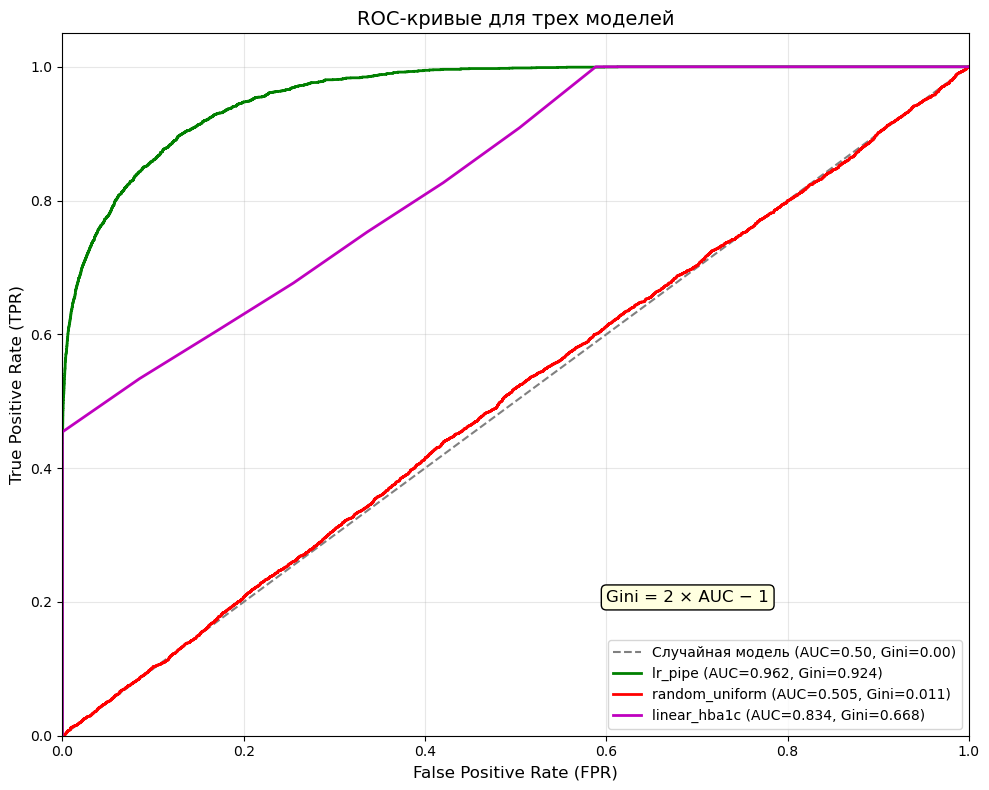


СРАВНЕНИЕ МОДЕЛЕЙ
Модель               AUC          Gini        
--------------------------------------------
lr_pipe              0.9619       0.9238      
linear_hba1c         0.8341       0.6682      
random_uniform       0.5055       0.0110      

Относительное улучшение lr_pipe по сравнению с linear_hba1c:
   AUC: +15.3%
  Gini: +38.2%


In [76]:
# Визуализируйте ROC-кривые и сравните значения AUC и Gini для трех моделей


# Получаем данные для ROC-кривых (если еще не получены)
fpr_lr, tpr_lr, _ = roc_curve(y_pipe_test, y_test_proba_lr_pipe)
fpr_random, tpr_random, _ = roc_curve(y_pipe_test, y_test_proba_random_uniform)
fpr_linear, tpr_linear, _ = roc_curve(y_pipe_test, y_test_proba_linear_hba1c)

# Создаем график
plt.figure(figsize=(10, 8))

# Диагональная линия (случайная модель)
plt.plot([0, 1], [0, 1], linestyle='--', c='gray', label='Случайная модель (AUC=0.50, Gini=0.00)')

# ROC-кривые для трех моделей
plt.plot(fpr_lr, tpr_lr, c='g', linewidth=2, 
         label=f'lr_pipe (AUC={auc_lr_pipe:.3f}, Gini={gini_lr_pipe:.3f})')
plt.plot(fpr_random, tpr_random, c='r', linewidth=2, 
         label=f'random_uniform (AUC={auc_random_uniform:.3f}, Gini={gini_random_uniform:.3f})')
plt.plot(fpr_linear, tpr_linear, c='m', linewidth=2, 
         label=f'linear_hba1c (AUC={auc_linear_hba1c:.3f}, Gini={gini_linear_hba1c:.3f})')

# Настройки графика
plt.title('ROC-кривые для трех моделей', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Добавление аннотации с формулой Gini
plt.text(0.6, 0.2, 'Gini = 2 × AUC − 1', fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

# Вывод сравнения в табличной форме
print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)
print(f"{'Модель':<20} {'AUC':<12} {'Gini':<12}")
print("-"*44)
print(f"{'lr_pipe':<20} {auc_lr_pipe:<12.4f} {gini_lr_pipe:<12.4f}")
print(f"{'linear_hba1c':<20} {auc_linear_hba1c:<12.4f} {gini_linear_hba1c:<12.4f}")
print(f"{'random_uniform':<20} {auc_random_uniform:<12.4f} {gini_random_uniform:<12.4f}")
print("="*60)

# Вывод относительного улучшения
print(f"\nОтносительное улучшение lr_pipe по сравнению с linear_hba1c:")
print(f"   AUC: +{(auc_lr_pipe - auc_linear_hba1c)/auc_linear_hba1c*100:.1f}%")
print(f"  Gini: +{(gini_lr_pipe - gini_linear_hba1c)/gini_linear_hba1c*100:.1f}%")